In [1]:
# imports
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
labelsize = 20
linewidth = 2
legend_width = 2
# markers = ['solid', 'dashed', 'dashdot', 'dotted', 'dashdotdotted']
markers = ['-', '--', '-.', ':', (0, (3, 5, 1, 5, 1, 5))]
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:cyan']
marker_phi = markers[0]
marker_p = markers[1]
marker_y_A = markers[2]
marker_y_C = markers[3]
markers_y_S = markers[4]
color_default = 'black'

## Ternary Electrolyte

In [3]:
# load the data
ternary_path = '../Data/TernaryElectrolyte.npz'
df_ternary =  np.load(ternary_path)

# extract the data
x_ternary = df_ternary['x']
phi_ternary = df_ternary['phi']
p_ternary = df_ternary['p']
y_A_ternary = df_ternary['y_A']
y_C_ternary = df_ternary['y_C']
y_S_ternary = 1 - y_A_ternary - y_C_ternary
index_ternary = df_ternary['index']
nF_ternary = df_ternary['nF']

/tmp/ipykernel_206344/521443608.py:25: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  [fig_.show() for fig_ in figs_ternary]


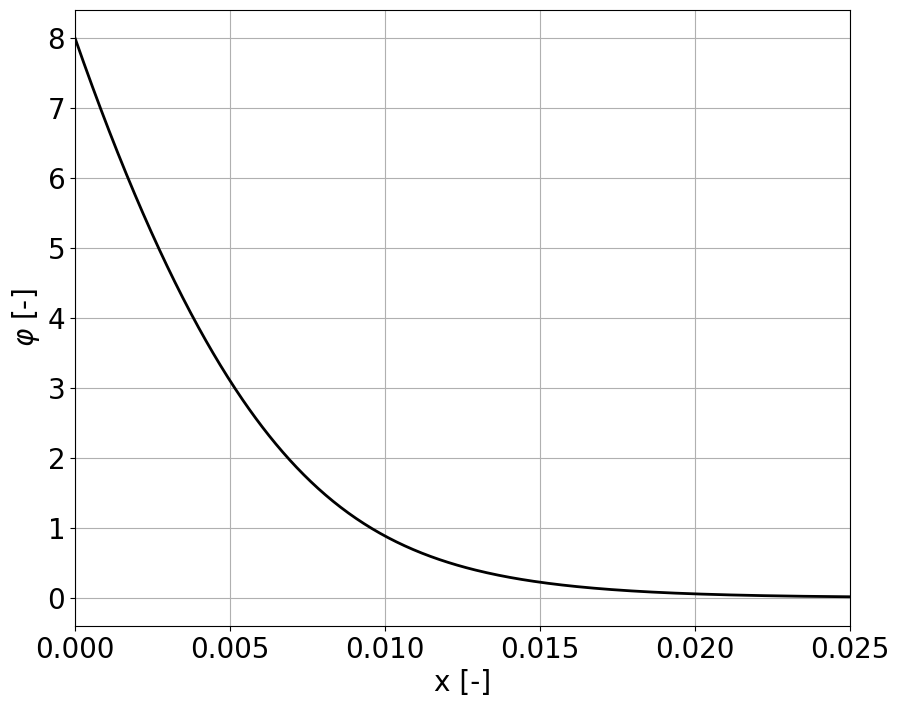

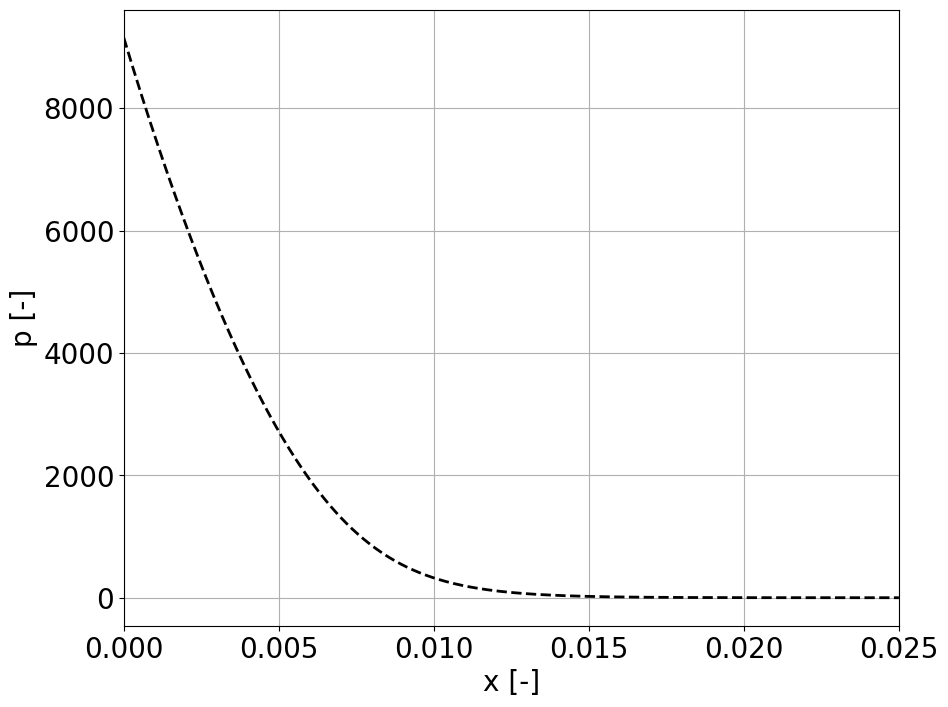

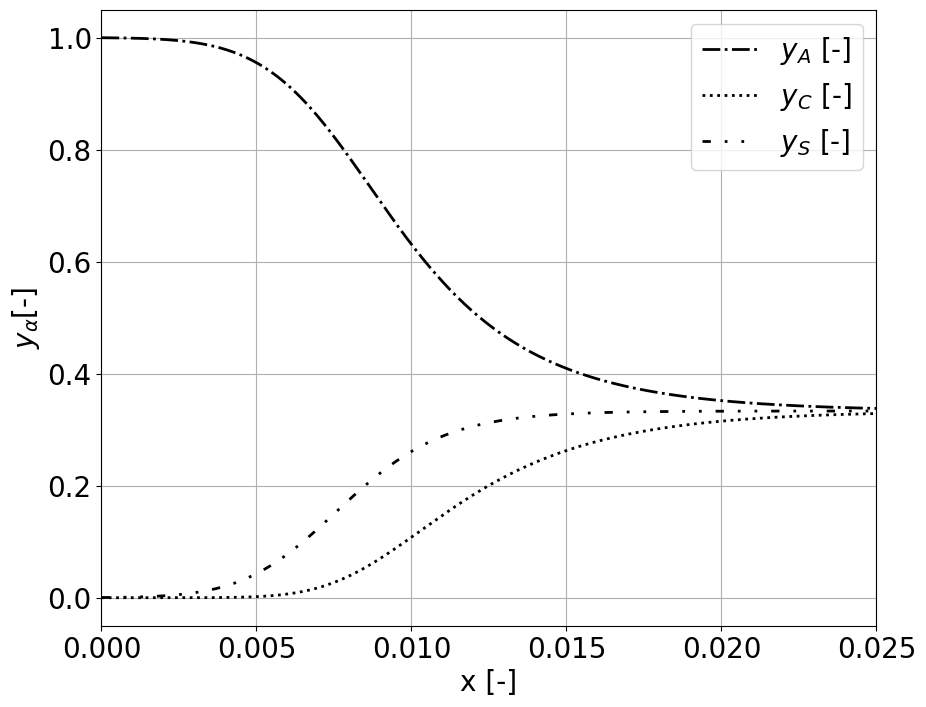

In [55]:
xlim = [0, 0.025]
figs_ternary = []
for property_, marker_, label_ in zip([phi_ternary, p_ternary], [marker_phi, marker_p], ['$\\varphi$ [-]', 'p [-]']):
    fig, axs = plt.subplots(1, 1, figsize=(10, 8))
    axs.plot(x_ternary, property_, lw=linewidth, linestyle=marker_, color=color_default, label=label_)
    axs.grid()
    axs.set_xlabel('x [-]', fontsize=labelsize)
    axs.set_ylabel(label_, fontsize=labelsize)
    axs.tick_params(axis='both', labelsize=labelsize)
    axs.set_xlim(xlim)
    # axs.legend(fontsize=labelsize, loc='upper right')
    figs_ternary.append(fig)

fig, axs = plt.subplots(1, 1, figsize=(10, 8))
for property_, marker_, label_ in zip([y_A_ternary, y_C_ternary, y_S_ternary], [marker_y_A, marker_y_C, markers_y_S], ['$y_A$ [-]', '$y_C$ [-]', '$y_S$ [-]']):
    axs.plot(x_ternary, property_, lw=linewidth, linestyle=marker_, color=color_default, label=label_)
    axs.grid()
axs.set_xlabel('x [-]', fontsize=labelsize)
axs.set_ylabel('$y_\\alpha$[-]', fontsize=labelsize)
axs.tick_params(axis='both', labelsize=labelsize)
axs.set_xlim(xlim)
axs.legend(fontsize=labelsize, loc='upper right')
figs_ternary.append(fig)

[fig_.show() for fig_ in figs_ternary]
figs_ternary[0].savefig('../Figures/Ternary/phi.pdf', bbox_inches='tight')
figs_ternary[1].savefig('../Figures/Ternary/p.pdf', bbox_inches='tight')
figs_ternary[2].savefig('../Figures/Ternary/y.pdf', bbox_inches='tight')

## Parameteranalysis

In [5]:
# load the data
ParamAna_path = '../Data/ParameterAnalysis/Lambda.npz'
df_ParamAna = np.load(ParamAna_path)

# extract the data
x_ParamAna = df_ParamAna['x']
phi_ParamAna = df_ParamAna['phi']
p_ParamAna = df_ParamAna['p']
y_A_ParamAna = df_ParamAna['y_A']
y_C_ParamAna = df_ParamAna['y_C']
y_S_ParamAna = 1 - y_A_ParamAna - y_C_ParamAna
phi_left_vec_ParamAna = df_ParamAna['phi_left_vec']
Lambda2_vec_ParamAna = df_ParamAna['Lambda2_vec']

<>:8: SyntaxWarning: invalid escape sequence '\l'
<>:25: SyntaxWarning: invalid escape sequence '\l'
<>:8: SyntaxWarning: invalid escape sequence '\l'
<>:25: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_206344/3382438229.py:8: SyntaxWarning: invalid escape sequence '\l'
  axs.plot(x_ParamAna[i][j], property_[i][j], lw=linewidth, linestyle=marker_, color=colors[j], label=f'$\lambda^2 = {Lambda2}$')
/tmp/ipykernel_206344/3382438229.py:25: SyntaxWarning: invalid escape sequence '\l'
  dummy = axs.plot([], [], lw=linewidth, linestyle=marker_, color=colors[j],  label=f'$\lambda^2 = {Lambda2}$')


[]

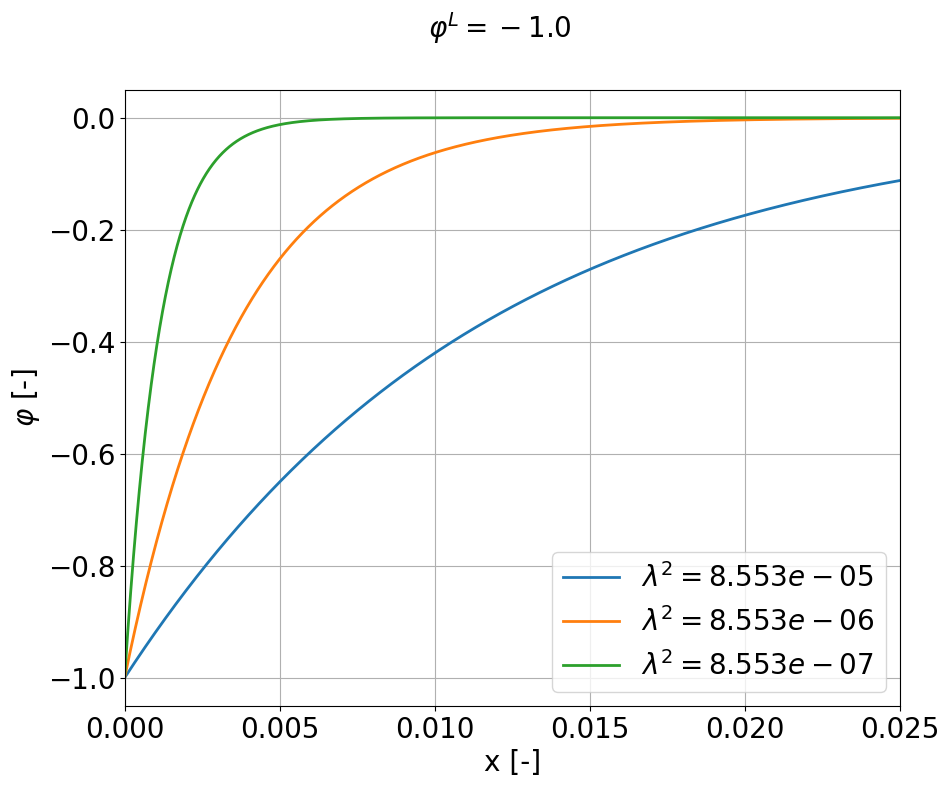

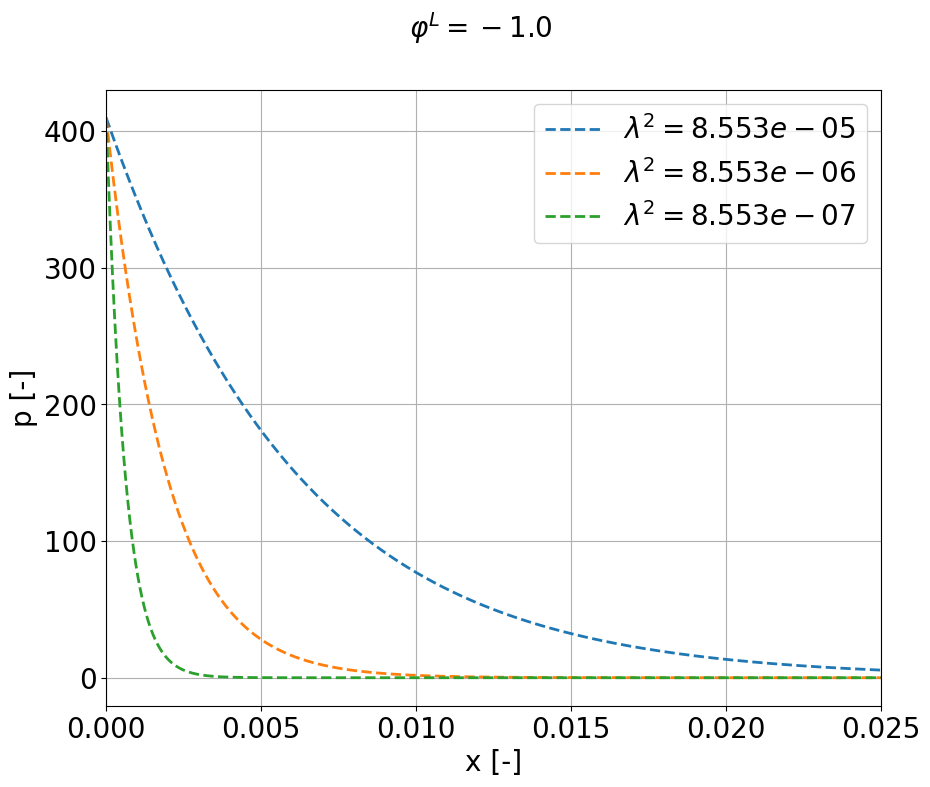

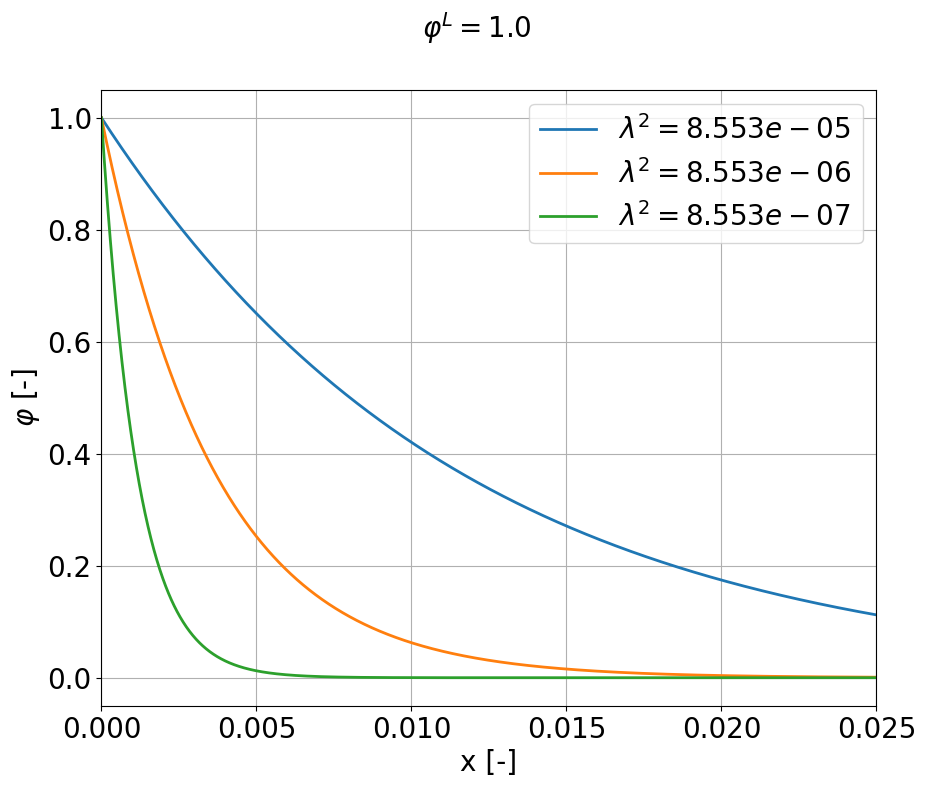

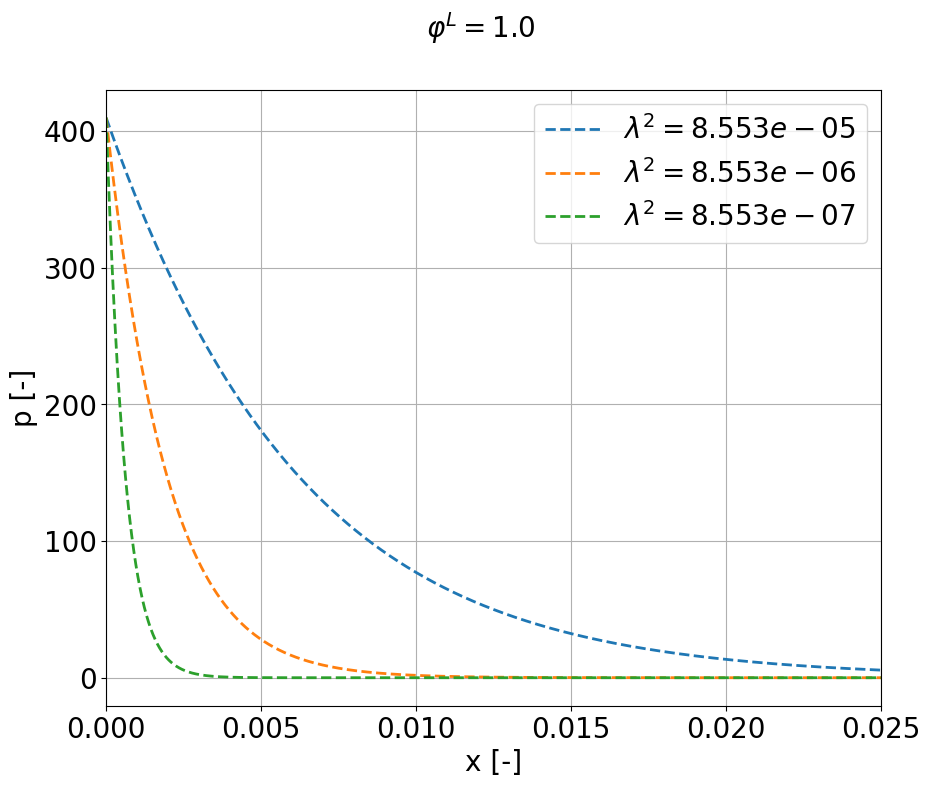

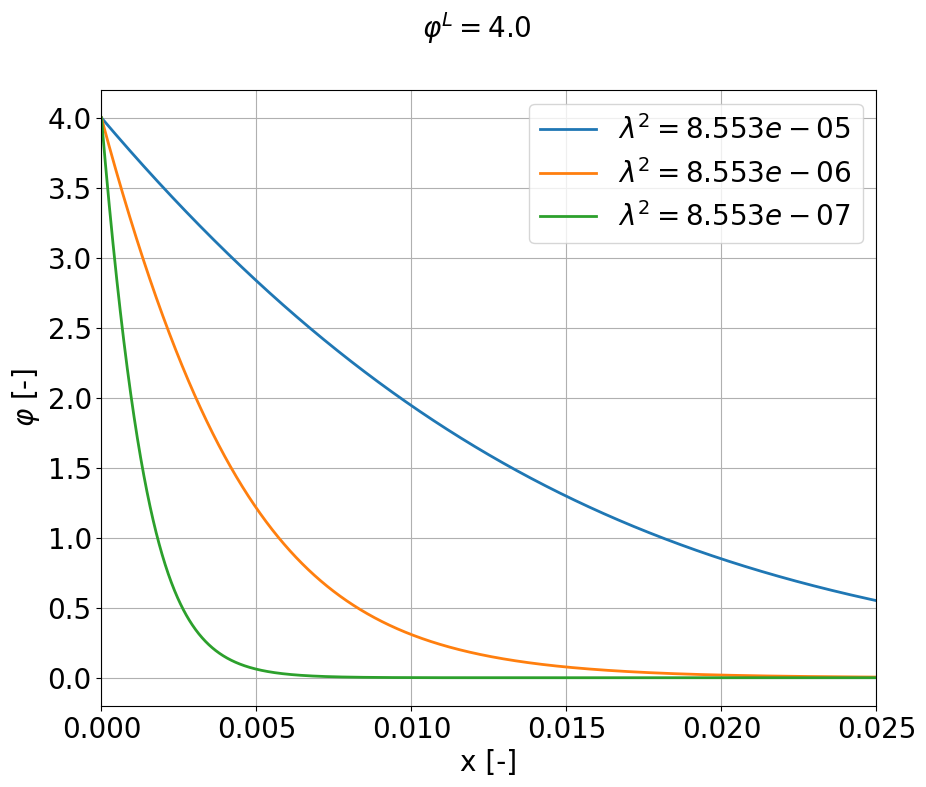

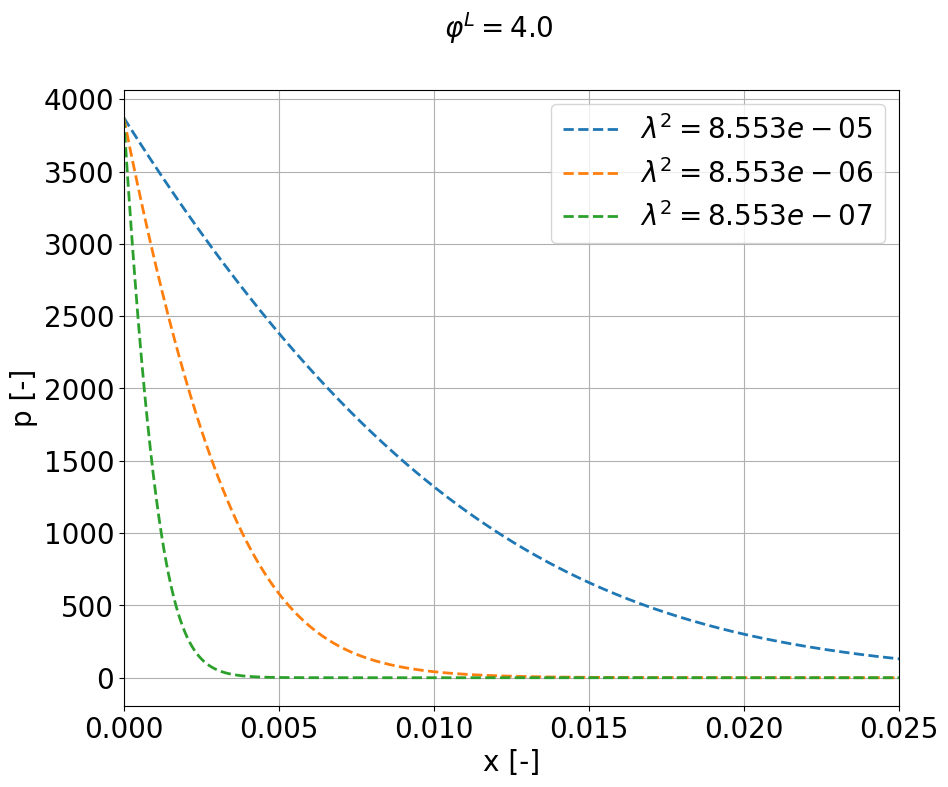

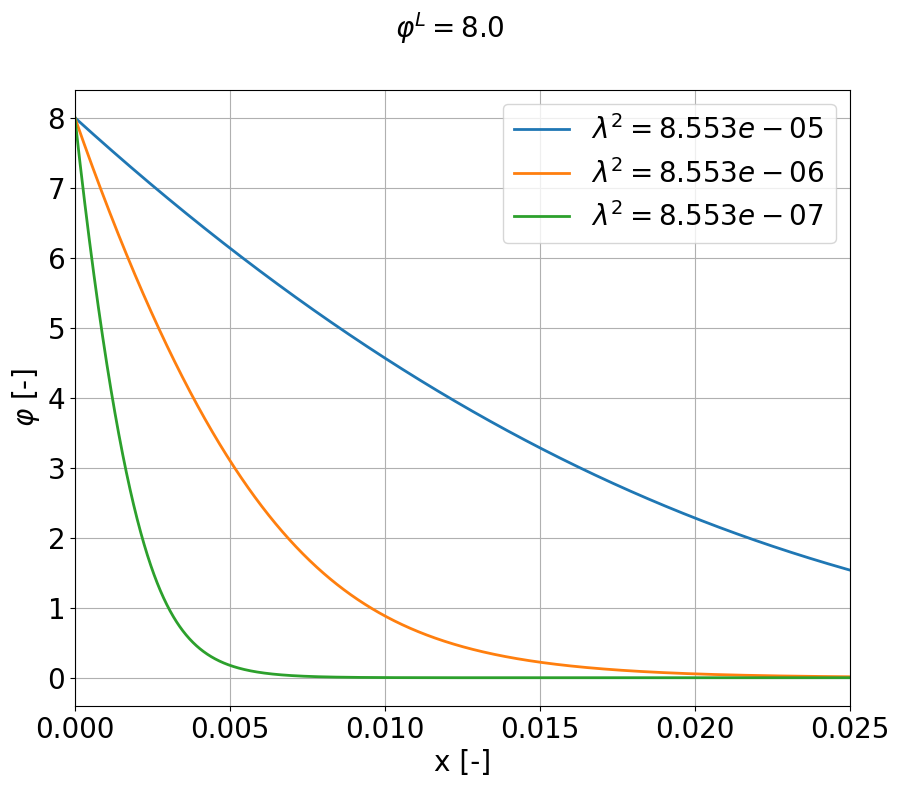

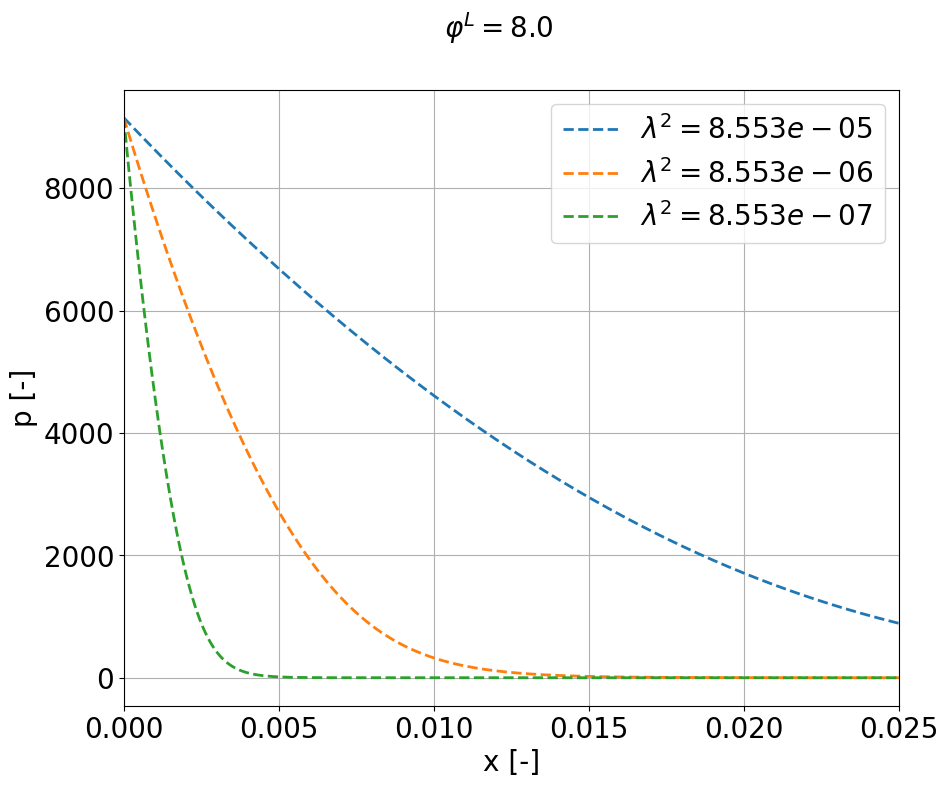

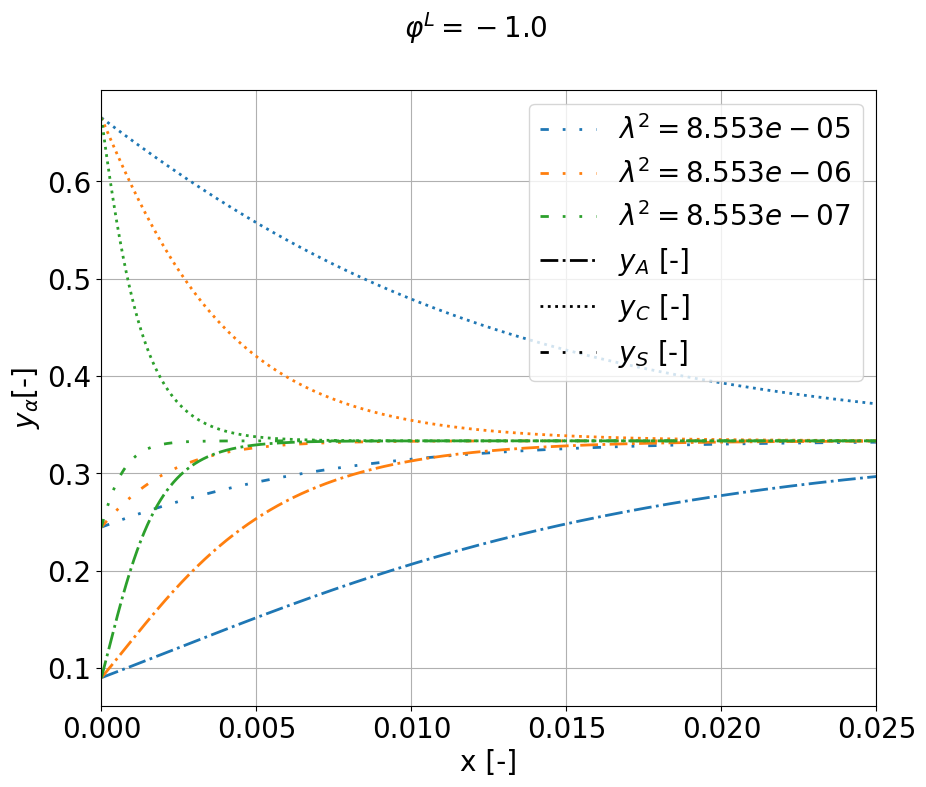

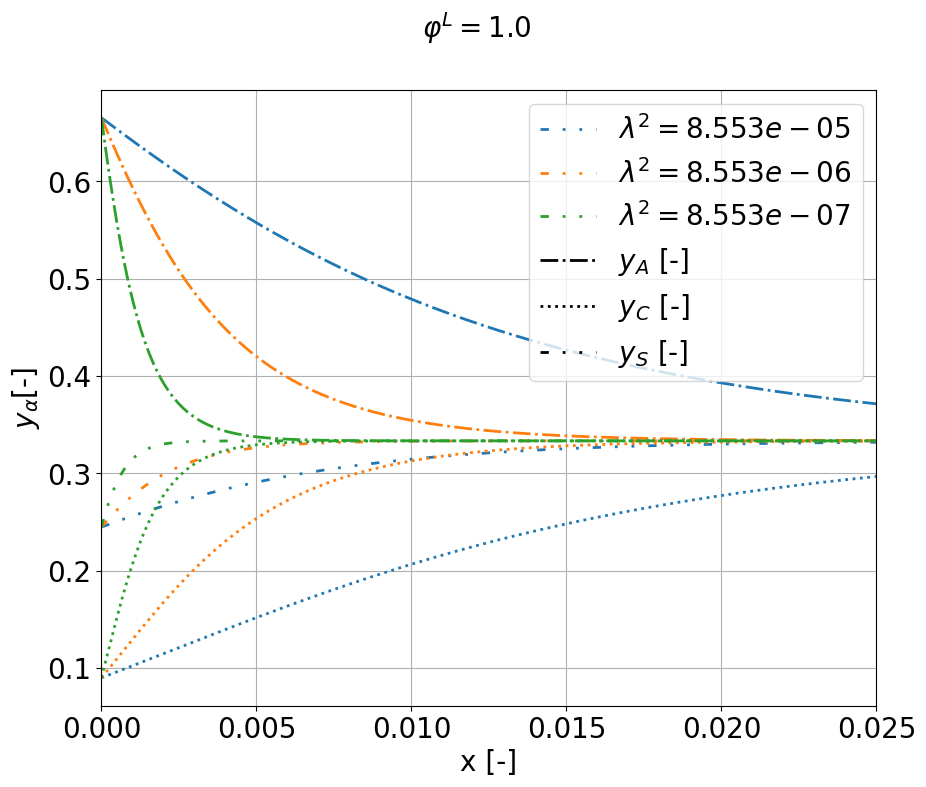

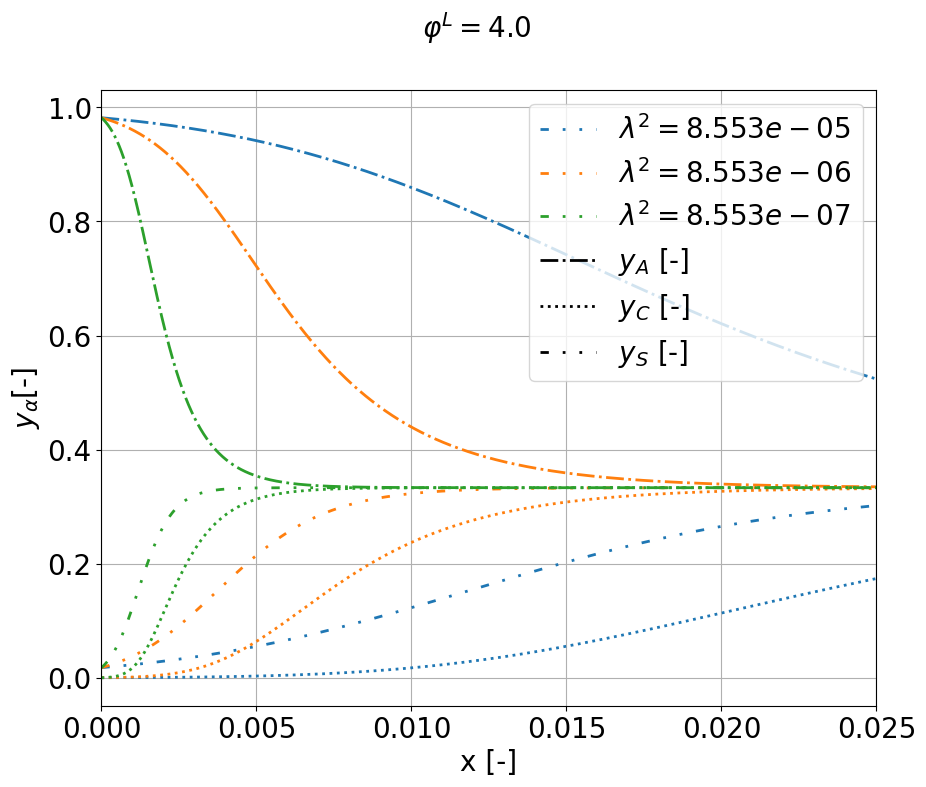

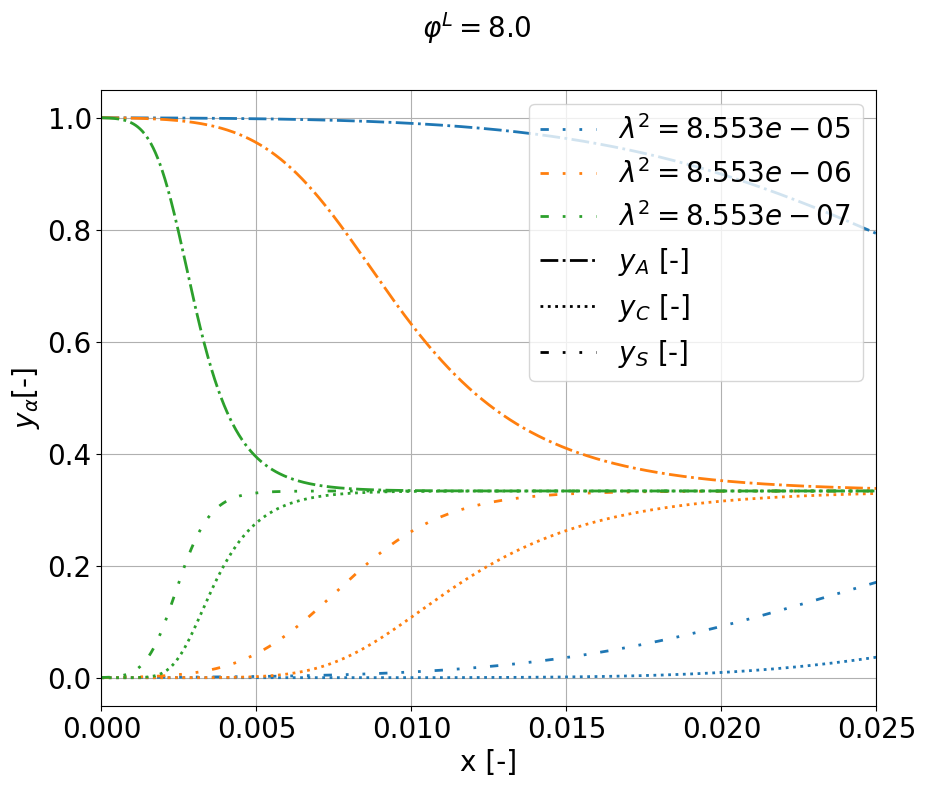

In [59]:
xlim = [0, 0.025]
figs_ParamAna = []
for i, phi_left in enumerate(phi_left_vec_ParamAna):
    for property_, marker_, label_, prop_label_ in zip([phi_ParamAna, p_ParamAna], [marker_phi, marker_p], ['$\\varphi$ [-]', 'p [-]'], ['phi', 'p']):
        fig, axs = plt.subplots(1, 1, figsize=(10, 8))
        fig.suptitle(f'$\\varphi^L = {phi_left}$', fontsize=labelsize)
        for j, Lambda2 in enumerate(Lambda2_vec_ParamAna):
            axs.plot(x_ParamAna[i][j], property_[i][j], lw=linewidth, linestyle=marker_, color=colors[j], label=f'$\lambda^2 = {Lambda2}$')
            axs.grid()
        axs.set_xlabel('x [-]', fontsize=labelsize)
        axs.set_ylabel(label_, fontsize=labelsize)
        axs.tick_params(axis='both', labelsize=labelsize)
        axs.set_xlim(xlim)
        axs.legend(fontsize=labelsize, loc='best')
        figs_ternary.append(fig)
        fig.savefig(f'../Figures/ParameterAnalysis/{prop_label_}/{prop_label_}_phiL{phi_left}_lambda{Lambda2}.pdf', bbox_inches='tight')

for i, phi_left in enumerate(phi_left_vec_ParamAna):
    fig, axs = plt.subplots(1, 1, figsize=(10, 8))
    fig.suptitle(f'$\\varphi^L = {phi_left}$', fontsize=labelsize)
    for j, Lambda2 in enumerate(Lambda2_vec_ParamAna):
        for property_, marker_, label_ in zip([y_A_ParamAna, y_C_ParamAna, y_S_ParamAna], [marker_y_A, marker_y_C, markers_y_S], ['$y_A$ [-]', '$y_C$ [-]', '$y_S$ [-]']):
            axs.plot(x_ParamAna[i][j], property_[i][j], lw=linewidth, linestyle=marker_, color=colors[j])
            axs.grid()
        dummy = axs.plot([], [], lw=linewidth, linestyle=marker_, color=colors[j],  label=f'$\lambda^2 = {Lambda2}$')
    for marker_, label_ in zip([marker_y_A, marker_y_C, markers_y_S], ['$y_A$ [-]', '$y_C$ [-]', '$y_S$ [-]']):
        dummy = axs.plot([], [], lw=linewidth, linestyle=marker_, color=color_default, label=label_)
    axs.set_xlabel('x [-]', fontsize=labelsize)
    axs.set_ylabel('$y_\\alpha$[-]', fontsize=labelsize)
    axs.tick_params(axis='both', labelsize=labelsize)
    axs.set_xlim(xlim)
    axs.legend(fontsize=labelsize, loc='best')
    figs_ternary.append(fig)
    fig.savefig(f'../Figures/ParameterAnalysis/y/y_phiL{phi_left}_lambda{Lambda2}.pdf', bbox_inches='tight')

[fig_.show() for fig_ in figs_ParamAna]

### Scale $\varphi$

In [7]:
df_scale_phi_path = '../Data/ParameterAnalysis/ScalingPhi.npz'
df_scale_phi = np.load(df_scale_phi_path)

phi_left_vector_scale_phi = df_scale_phi['phi_left_vector']
phi_scale_phi = df_scale_phi['phi']
phi_scaled_scale_phi = df_scale_phi['phi_scaled']
x_scale_phi = df_scale_phi['x']

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_206344/195806608.py:3: SyntaxWarning: invalid escape sequence '\d'
  for property_, marker_, label_ in zip([phi_scale_phi, phi_scaled_scale_phi], [marker_phi, marker_phi], ['$\\varphi$ [-]', '$\\varphi/\delta \\varphi$ [-]']):
/tmp/ipykernel_206344/195806608.py:6: SyntaxWarning: invalid escape sequence '\d'
  axs.plot(x_scale_phi[i], property_[i], lw=linewidth, linestyle=marker_, color=colors[i], label=f'$\delta \\varphi = {phi_left}$')
/tmp/ipykernel_206344/195806608.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  [fig_.show() for fig_ in figs_scale_phi]


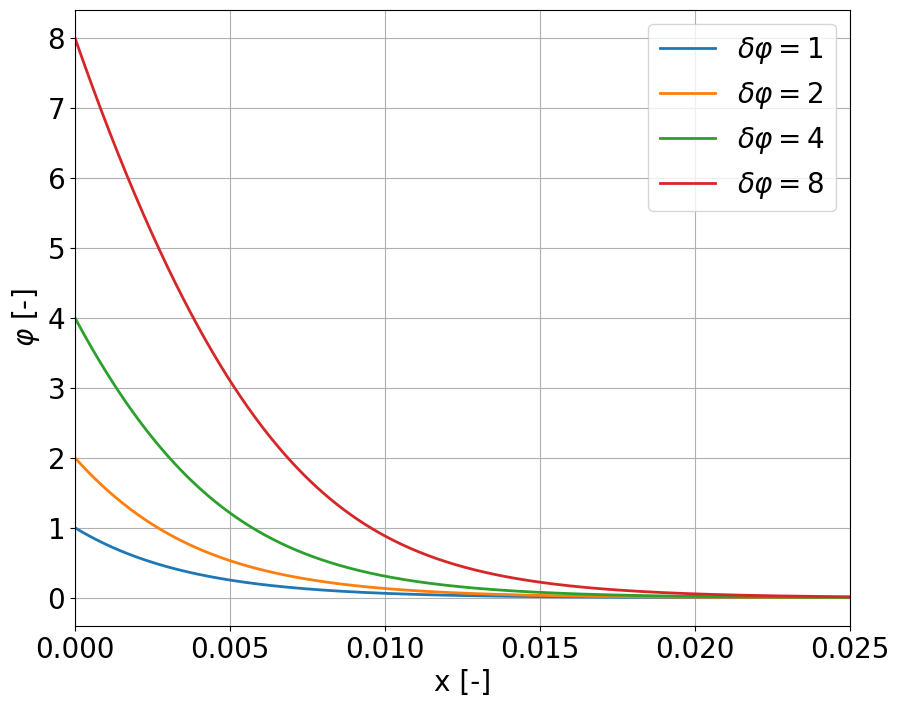

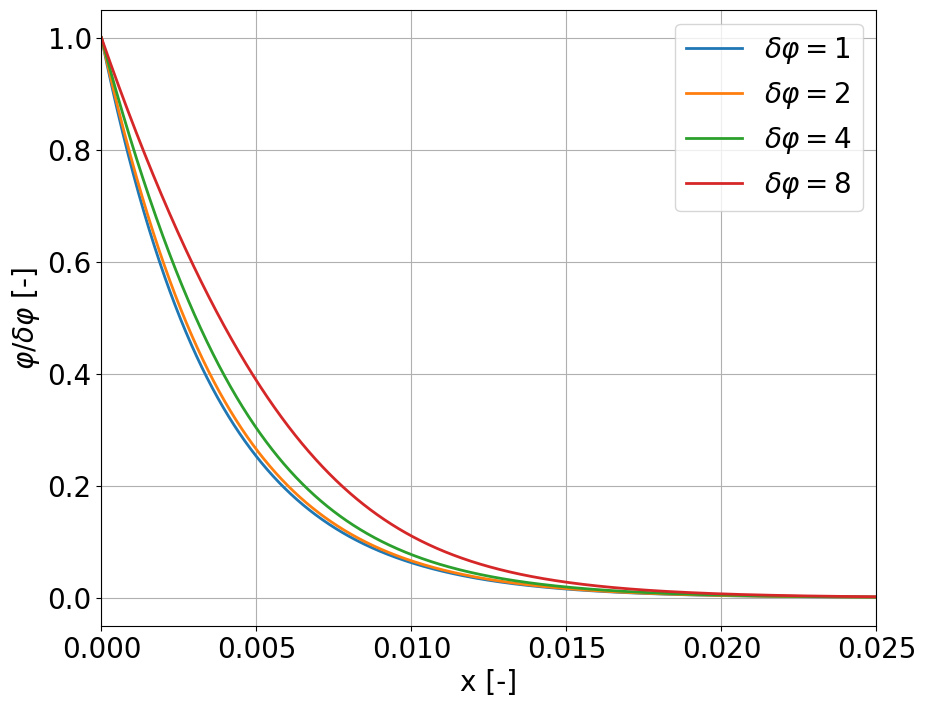

In [60]:
xlim = [0, 0.025]
figs_scale_phi = []
for property_, marker_, label_ in zip([phi_scale_phi, phi_scaled_scale_phi], [marker_phi, marker_phi], ['$\\varphi$ [-]', '$\\varphi/\delta \\varphi$ [-]']):
    fig, axs = plt.subplots(1, 1, figsize=(10, 8))
    for i, phi_left in enumerate(phi_left_vector_scale_phi):
        axs.plot(x_scale_phi[i], property_[i], lw=linewidth, linestyle=marker_, color=colors[i], label=f'$\delta \\varphi = {phi_left}$')
    axs.grid()
    axs.set_xlabel('x [-]', fontsize=labelsize)
    axs.set_ylabel(label_, fontsize=labelsize)
    axs.tick_params(axis='both', labelsize=labelsize)
    axs.set_xlim(xlim)
    axs.legend(fontsize=labelsize, loc='best')
    figs_scale_phi.append(fig)

[fig_.show() for fig_ in figs_scale_phi]
figs_scale_phi[0].savefig('../Figures/ParameterAnalysis/ScalePhi/phi_unscaled.pdf', bbox_inches='tight')
figs_scale_phi[1].savefig('../Figures/ParameterAnalysis/ScalePhi/phi_scaled.pdf', bbox_inches='tight')

### Atomic Fractions at Electrode ($y_\alpha^L(\varphi^L)$)

In [9]:
df_fractions_electrode_path = '../Data/ParameterAnalysis/FractionsHeightLeft.npz'
df_fractions_electrode = np.load(df_fractions_electrode_path)

phi_left_vector_fractions_electrode = df_fractions_electrode['phi_left_vec']
y_A_fractions_electrode = df_fractions_electrode['y_A']
y_C_fractions_electrode = df_fractions_electrode['y_C']
y_S_fractions_electrode = df_fractions_electrode['y_S']

<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_206344/2724026927.py:5: SyntaxWarning: invalid escape sequence '\d'
  axs.set_xlabel('$\delta \\varphi$ [-]', fontsize=labelsize)
/tmp/ipykernel_206344/2724026927.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_fractions_electrode.show()


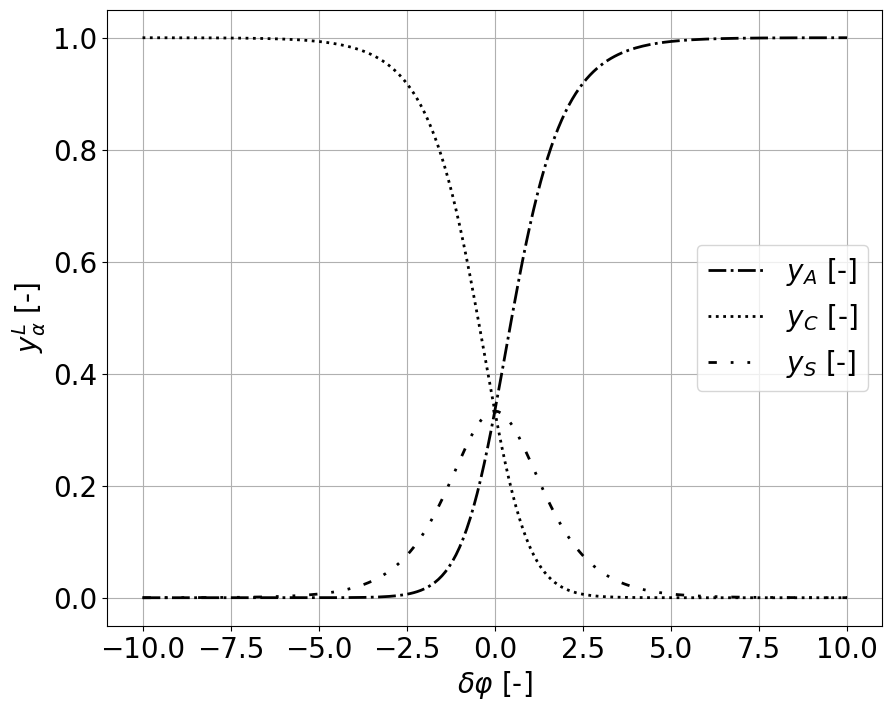

In [61]:
fig_fractions_electrode, axs = plt.subplots(1, 1, figsize=(10, 8))
for property_, marker_, label_ in zip([y_A_fractions_electrode, y_C_fractions_electrode, y_S_fractions_electrode], [marker_y_A, marker_y_C, markers_y_S], ['$y_A$ [-]', '$y_C$ [-]', '$y_S$ [-]']):
    axs.plot(phi_left_vector_fractions_electrode, property_[:,0], lw=linewidth, linestyle=marker_, color=color_default, label=label_)
axs.grid()
axs.set_xlabel('$\delta \\varphi$ [-]', fontsize=labelsize)
axs.set_ylabel('$y_\\alpha^L$ [-]', fontsize=labelsize)
axs.tick_params(axis='both', labelsize=labelsize)
axs.legend(fontsize=labelsize, loc='best')

fig_fractions_electrode.show()
fig_fractions_electrode.savefig('../Figures/ParameterAnalysis/FractionsAtElectrode.pdf', bbox_inches='tight')

## Comparison to classical Nernst-Planck model

### Single plots

In [11]:
# Potential of 1 [-]
df_NP_1_path = '../Data/PoissonBoltzmann_1.npz'
df_NP_1 = np.load(df_NP_1_path)

# DGM
x_DGM_1 = df_NP_1['x_DGM_01']
phi_DGM_1 = df_NP_1['phi_DGM_01']
p_DGM_1 = df_NP_1['p_DGM_01']
y_A_DGM_1 = df_NP_1['y_A_DGM_01']
y_C_DGM_1 = df_NP_1['y_C_DGM_01']
y_S_DGM_1 = df_NP_1['y_S_DGM_01']
# NP
x_NP_1 = df_NP_1['x_PB_01']
phi_NP_1 = df_NP_1['phi_PB_01']
p_NP_1 = df_NP_1['p_PB_01']
y_A_NP_1 = df_NP_1['y_A_PB_01']
y_C_NP_1 = df_NP_1['y_C_PB_01']
y_S_NP_1 = df_NP_1['y_S_PB_01']

# Potential of 10 [-]
df_NP_10_path = '../Data/PoissonBoltzmann_10.npz'
df_NP_10 = np.load(df_NP_10_path)

# DGM
x_DGM_10 = df_NP_10['x_DGM_10']
phi_DGM_10 = df_NP_10['phi_DGM_10']
p_DGM_10 = df_NP_10['p_DGM_10']
y_A_DGM_10 = df_NP_10['y_A_DGM_10']
y_C_DGM_10 = df_NP_10['y_C_DGM_10']
y_S_DGM_10 = df_NP_10['y_S_DGM_10']
# NP
x_NP_10 = df_NP_10['x_PB_10']
phi_NP_10 = df_NP_10['phi_PB_10']
p_NP_10 = df_NP_10['p_PB_10']
y_A_NP_10 = df_NP_10['y_A_PB_10']
y_C_NP_10 = df_NP_10['y_C_PB_10']
y_S_NP_10 = df_NP_10['y_S_PB_10']

<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:19: SyntaxWarning: invalid escape sequence '\d'
<>:40: SyntaxWarning: invalid escape sequence '\d'
<>:54: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:19: SyntaxWarning: invalid escape sequence '\d'
<>:40: SyntaxWarning: invalid escape sequence '\d'
<>:54: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_206344/193024196.py:6: SyntaxWarning: invalid escape sequence '\d'
  fig.suptitle('$\delta \\varphi = 1$ [-]', fontsize=labelsize)
/tmp/ipykernel_206344/193024196.py:19: SyntaxWarning: invalid escape sequence '\d'
  fig.suptitle('$\delta \\varphi = 1$ [-]', fontsize=labelsize)
/tmp/ipykernel_206344/193024196.py:40: SyntaxWarning: invalid escape sequence '\d'
  fig.suptitle('$\delta \\varphi = 10$ [-]', fontsize=labelsize)
/tmp/ipykernel_206344/193024196.py:54: SyntaxWarning: invalid escape sequence '\d'
  fig.suptitle('$\delta \\varphi = 10$ [-]', fontsize=labelsize)
/tmp/

[None, None, None]

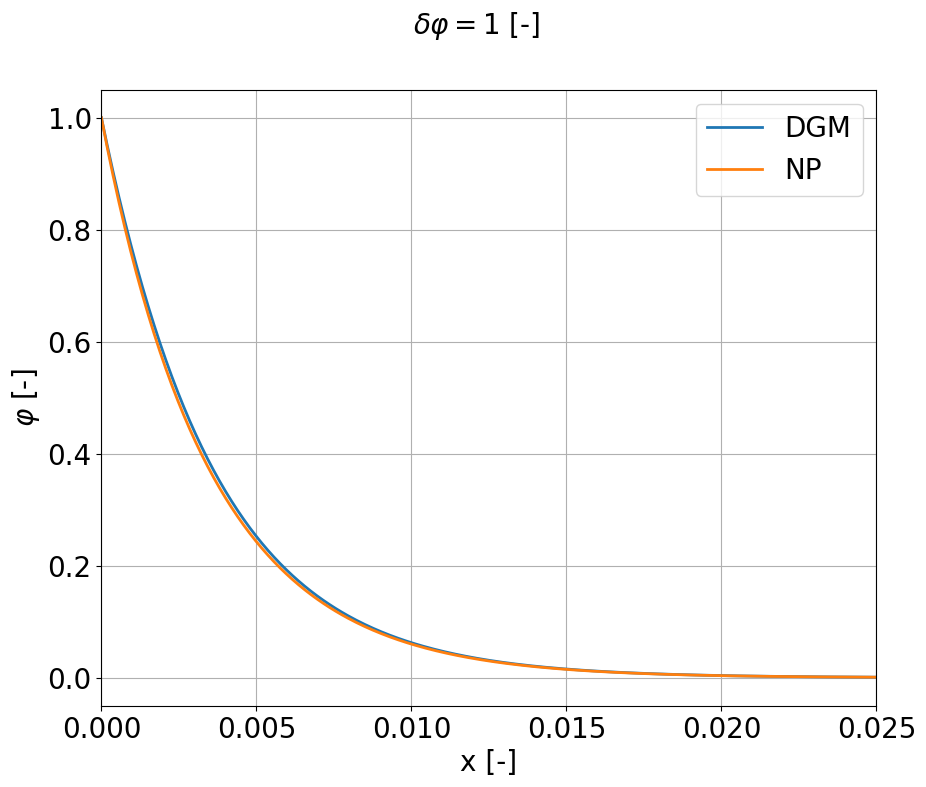

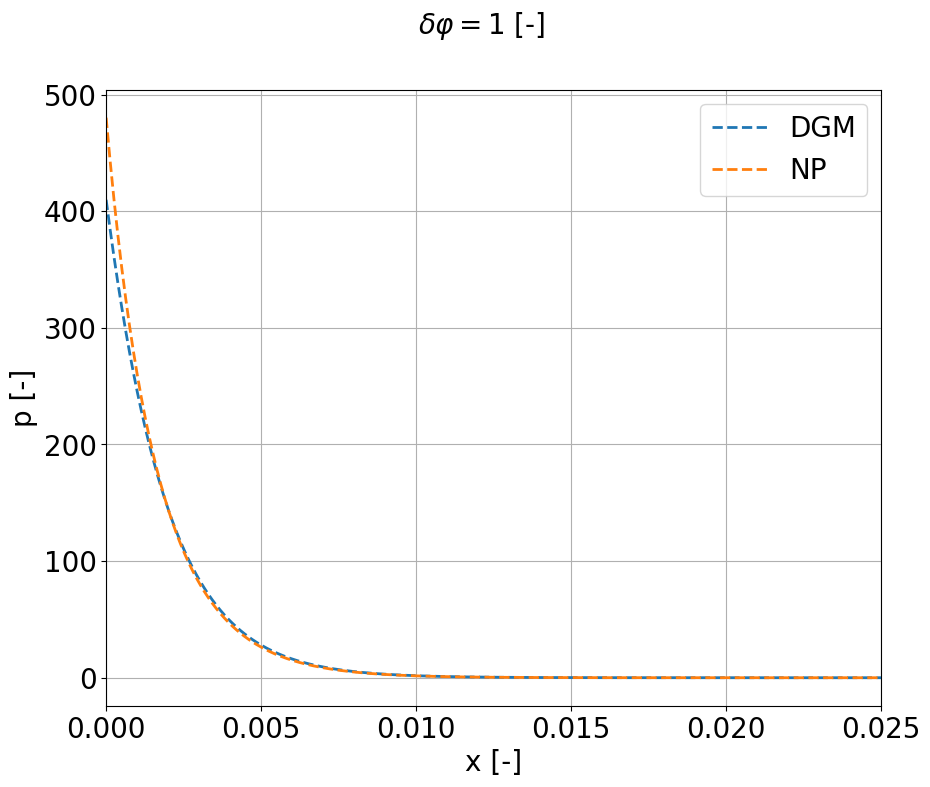

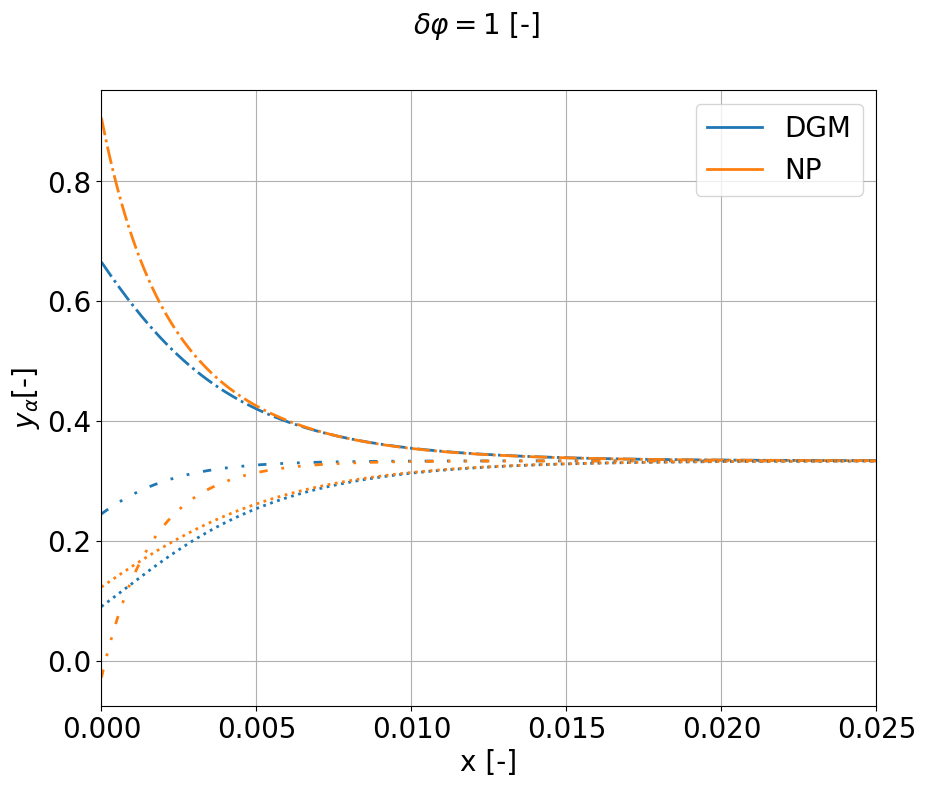

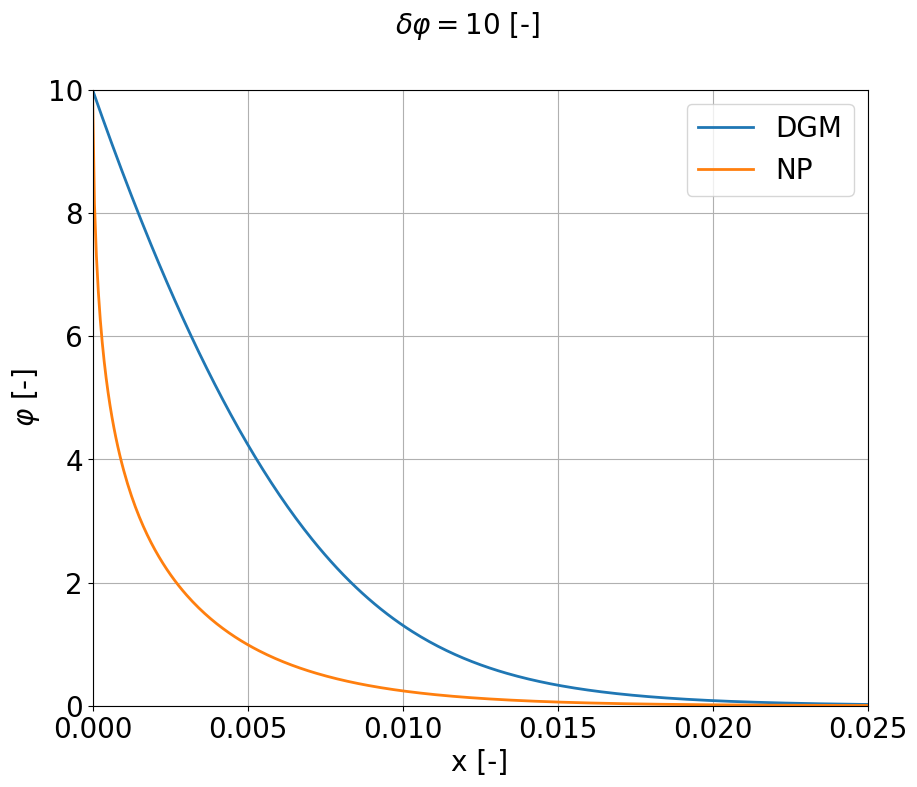

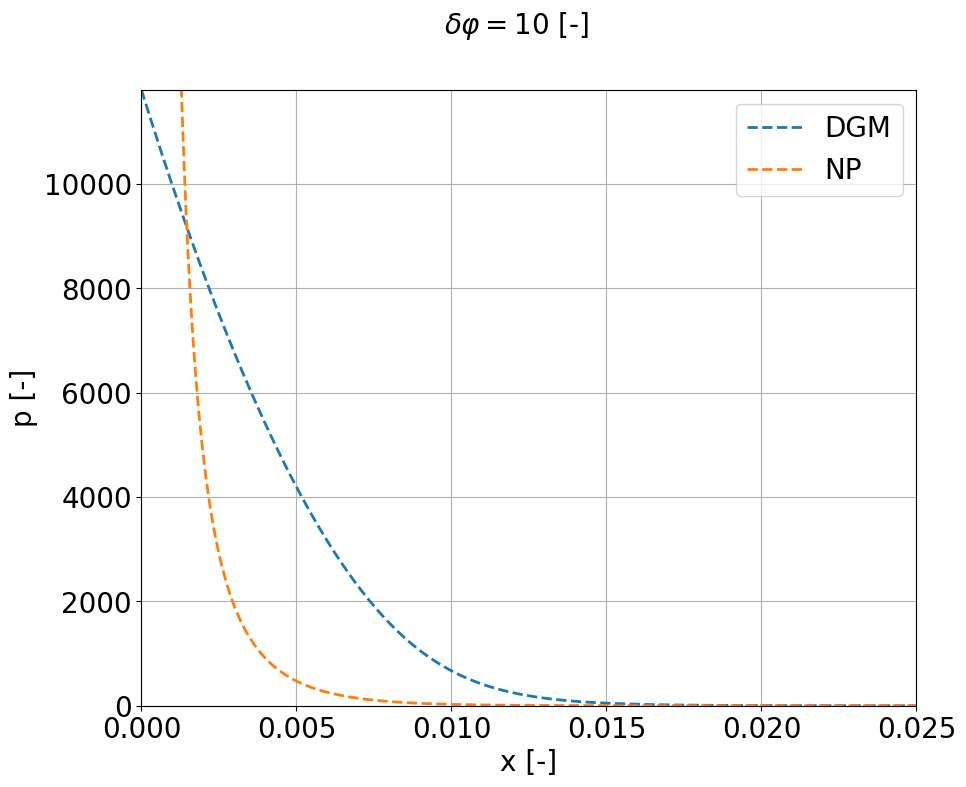

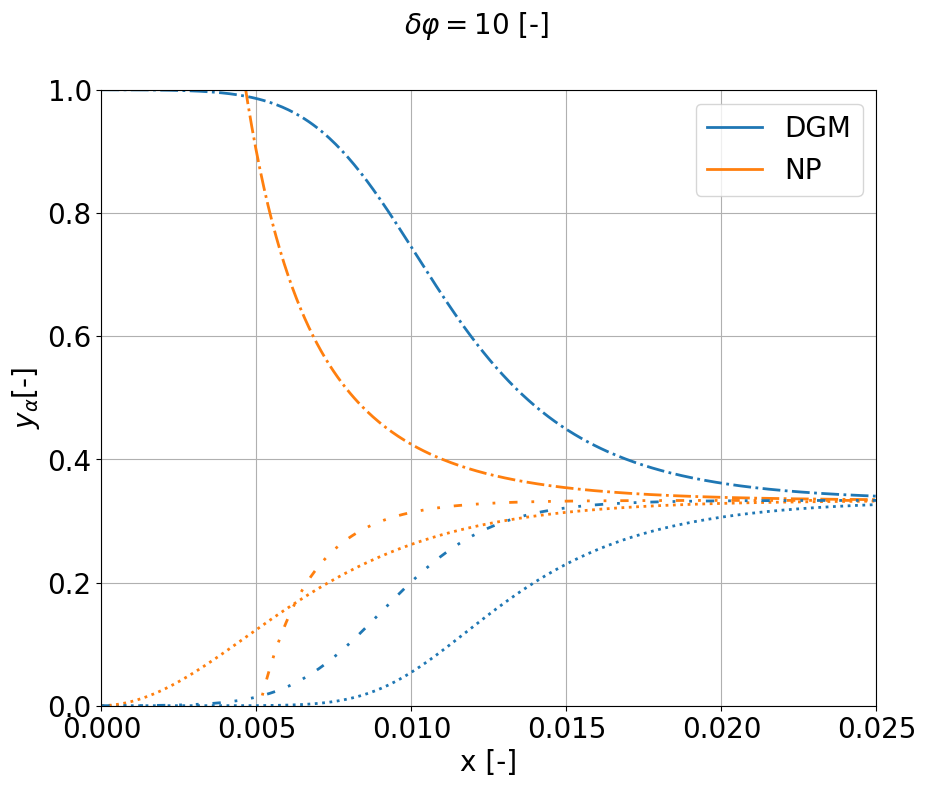

In [65]:
xlim = 0.025
# Potential 0f 1 [-]
figs_NP_1 = []
for property_DGM, property_NP, marker_, label_, prop_label_ in zip([phi_DGM_1, p_DGM_1], [phi_NP_1, p_NP_1], [marker_phi, marker_p], ['$\\varphi$ [-]', 'p [-]'], ['phi', 'p']):
    fig, axs = plt.subplots(1, 1, figsize=(10, 8))
    fig.suptitle('$\delta \\varphi = 1$ [-]', fontsize=labelsize)
    axs.plot(x_DGM_1, property_DGM, lw=linewidth, linestyle=marker_, color=colors[0], label='DGM')
    axs.plot(x_NP_1, property_NP, lw=linewidth, linestyle=marker_, color=colors[1], label='NP')
    axs.grid()
    axs.set_xlabel('x [-]', fontsize=labelsize)
    axs.set_ylabel(label_, fontsize=labelsize)
    axs.tick_params(axis='both', labelsize=labelsize)
    axs.set_xlim([0, xlim])
    axs.legend(fontsize=labelsize, loc='best')
    figs_NP_1.append(fig)
    fig.savefig(f'../Figures/Comparison_NP/{prop_label_}/{prop_label_}_phi_01.pdf', bbox_inches='tight')

fig, axs = plt.subplots(1, 1, figsize=(10, 8))
fig.suptitle('$\delta \\varphi = 1$ [-]', fontsize=labelsize)
for property_DGM, property_NP, marker_, label_ in zip([y_A_DGM_1, y_C_DGM_1, y_S_DGM_1], [y_A_NP_1, y_C_NP_1, y_S_NP_1], [marker_y_A, marker_y_C, markers_y_S], ['$y_A$ [-]', '$y_C$ [-]', '$y_S$ [-]']):
    axs.plot(x_DGM_1, property_DGM, lw=linewidth, linestyle=marker_, color=colors[0])
    axs.plot(x_NP_1, property_NP, lw=linewidth, linestyle=marker_, color=colors[1])
dummy = axs.plot([], [], lw=linewidth, linestyle='solid', color=colors[0], label='DGM')
dummy = axs.plot([], [], lw=linewidth, linestyle='solid', color=colors[1], label='NP')
axs.grid()
axs.set_xlabel('x [-]', fontsize=labelsize)
axs.set_ylabel('$y_\\alpha$[-]', fontsize=labelsize)
axs.tick_params(axis='both', labelsize=labelsize)
axs.set_xlim([0, xlim])
axs.legend(fontsize=labelsize, loc='best')
figs_NP_1.append(fig)
fig.savefig(f'../Figures/Comparison_NP/y/y_phi_01.pdf', bbox_inches='tight')



# Potential 0f 10 [-]
figs_NP_10 = []
for property_DGM, property_NP, marker_, label_, prop_label_ in zip([phi_DGM_10, p_DGM_10], [phi_NP_10, p_NP_10], [marker_phi, marker_p], ['$\\varphi$ [-]', 'p [-]'], ['phi', 'p']):
    fig, axs = plt.subplots(1, 1, figsize=(10, 8))
    fig.suptitle('$\delta \\varphi = 10$ [-]', fontsize=labelsize)
    axs.plot(x_DGM_10, property_DGM, lw=linewidth, linestyle=marker_, color=colors[0], label='DGM')
    axs.plot(x_NP_10, property_NP, lw=linewidth, linestyle=marker_, color=colors[1], label='NP')
    axs.grid()
    axs.set_xlabel('x [-]', fontsize=labelsize)
    axs.set_ylabel(label_, fontsize=labelsize)
    axs.tick_params(axis='both', labelsize=labelsize)
    axs.set_xlim([0, xlim])
    axs.set_ylim(np.min(property_DGM), np.max(property_DGM))
    axs.legend(fontsize=labelsize, loc='best')
    figs_NP_10.append(fig)
    fig.savefig(f'../Figures/Comparison_NP/{prop_label_}/{prop_label_}_phi_10.pdf', bbox_inches='tight')

fig, axs = plt.subplots(1, 1, figsize=(10, 8))
fig.suptitle('$\delta \\varphi = 10$ [-]', fontsize=labelsize)
for property_DGM, property_NP, marker_, label_ in zip([y_A_DGM_10, y_C_DGM_10, y_S_DGM_10], [y_A_NP_10, y_C_NP_10, y_S_NP_10], [marker_y_A, marker_y_C, markers_y_S], ['$y_A$ [-]', '$y_C$ [-]', '$y_S$ [-]']):
    axs.plot(x_DGM_10, property_DGM, lw=linewidth, linestyle=marker_, color=colors[0])
    axs.plot(x_NP_10, property_NP, lw=linewidth, linestyle=marker_, color=colors[1])
dummy = axs.plot([], [], lw=linewidth, linestyle='solid', color=colors[0], label='DGM')
dummy = axs.plot([], [], lw=linewidth, linestyle='solid', color=colors[1], label='NP')
axs.grid()
axs.set_xlabel('x [-]', fontsize=labelsize)
axs.set_ylabel('$y_\\alpha$[-]', fontsize=labelsize)
axs.tick_params(axis='both', labelsize=labelsize)
axs.set_xlim([0, xlim])
axs.set_ylim([0, 1])
axs.legend(fontsize=labelsize, loc='best')
figs_NP_10.append(fig)
fig.savefig(f'../Figures/Comparison_NP/y/y_phi_10.pdf', bbox_inches='tight')

[fig_.show() for fig_ in figs_NP_1]
[fig_.show() for fig_ in figs_NP_10]

### Convergence between NP and DGM

In [13]:
Convergence_NP_path = '../Data/PoissonBoltzmann_Convergence.npz'
Convergence_NP = np.load(Convergence_NP_path)

phi_left_vec_NP = Convergence_NP['phi_left_vec']
# phi_error_L2_NP = Convergence_NP['phi_error_L2']
# p_error_L2_NP = Convergence_NP['p_error_L2']
y_A_error_L2_NP = Convergence_NP['y_A_error_L2']
y_C_error_L2_NP = Convergence_NP['y_C_error_L2']
y_S_error_L2_NP = Convergence_NP['y_S_error_L2']
# phi_error_inf_NP = Convergence_NP['phi_error_inf']
# p_error_inf_NP = Convergence_NP['p_error_inf']
y_A_error_inf_NP = Convergence_NP['y_A_error_inf']
y_C_error_inf_NP = Convergence_NP['y_C_error_inf']
y_S_error_inf_NP = Convergence_NP['y_S_error_inf']

# for rescaling to physical values
e0 = 1.602e-19 # [As]
k = 1.381e-23 # [J/K]
T = 293.75 # [K]
phi_left_vec_physical_NP = phi_left_vec_NP * (k*T)/e0

<>:9: SyntaxWarning: invalid escape sequence '\d'
<>:10: SyntaxWarning: invalid escape sequence '\d'
<>:9: SyntaxWarning: invalid escape sequence '\d'
<>:10: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_206344/1659975726.py:9: SyntaxWarning: invalid escape sequence '\d'
  axs.set_xlabel('$\delta \\varphi [-]$', fontsize=labelsize)
/tmp/ipykernel_206344/1659975726.py:10: SyntaxWarning: invalid escape sequence '\d'
  axs_twiny.set_xlabel('$\delta \\varphi [V]$', fontsize=labelsize)
/tmp/ipykernel_206344/1659975726.py:4: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  axs.plot(phi_left_vec_NP, property_, 'o-', label=label_, lw=linewidth, ms=linewidth, color=color_default, linestyle=marker_)
/tmp/ipykernel_206344/1659975726.py:7: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). T

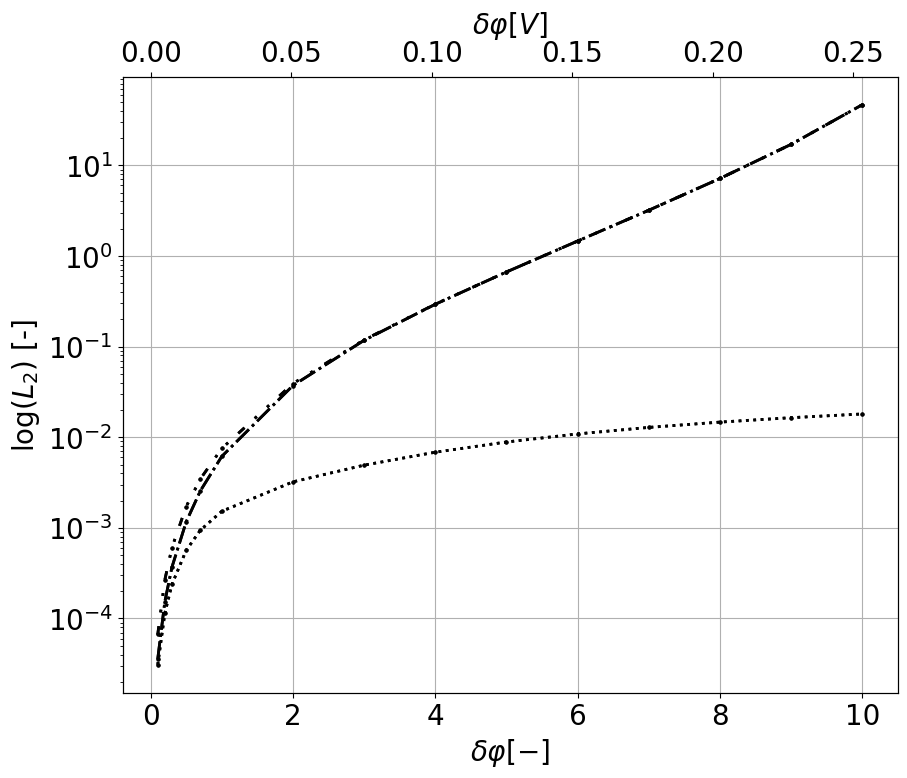

In [67]:
# Log-log plot of L2-error
fig_L2_NP, axs = plt.subplots(1, 1, figsize=(10, 8))
for property_, marker_, label_ in zip([y_A_error_L2_NP, y_C_error_L2_NP, y_S_error_L2_NP], [marker_y_A, marker_y_C, markers_y_S], ['$y_A$', '$y_C$', '$y_S$']):
    axs.plot(phi_left_vec_NP, property_, 'o-', label=label_, lw=linewidth, ms=linewidth, color=color_default, linestyle=marker_)
axs_twiny = axs.twiny()
for property_, marker_ in zip([y_A_error_L2_NP, y_C_error_L2_NP, y_S_error_L2_NP], [marker_y_A, marker_y_C, markers_y_S]):
    axs_twiny.plot(phi_left_vec_physical_NP, property_, 'o-', lw=linewidth, ms=linewidth, color=color_default, linestyle=marker_)
axs.set_yscale('log')
axs.set_xlabel('$\delta \\varphi [-]$', fontsize=labelsize)
axs_twiny.set_xlabel('$\delta \\varphi [V]$', fontsize=labelsize)
axs.set_ylabel('log($L_2$) [-]', fontsize=labelsize)
axs.tick_params(axis='both', labelsize=labelsize)
axs_twiny.tick_params(axis='both', labelsize=labelsize)
axs.grid()

fig_L2_NP.show()
fig_L2_NP.savefig('../Figures/Comparison_NP/L2_error.pdf', bbox_inches='tight')

## Solvation

In [15]:
data_solvation_path = '../Data/Solvation.npz'
data_solvation = np.load(data_solvation_path)

x_solvation = data_solvation['x']
phi_solvation = data_solvation['phi']
p_solvation = data_solvation['p']
y_A_solvation = data_solvation['y_A']
y_C_solvation = data_solvation['y_C']
y_S_solvation = data_solvation['y_S']
Solvation_vec = data_solvation['Solvation_vec']

<>:6: SyntaxWarning: invalid escape sequence '\k'
<>:20: SyntaxWarning: invalid escape sequence '\k'
<>:36: SyntaxWarning: invalid escape sequence '\k'
<>:6: SyntaxWarning: invalid escape sequence '\k'
<>:20: SyntaxWarning: invalid escape sequence '\k'
<>:36: SyntaxWarning: invalid escape sequence '\k'
/tmp/ipykernel_206344/3354955001.py:6: SyntaxWarning: invalid escape sequence '\k'
  axs.plot(x_solvation[i], property_[i], lw=linewidth, linestyle=marker_, color=colors[i], label=f'$\kappa = {Solvation}$')
/tmp/ipykernel_206344/3354955001.py:20: SyntaxWarning: invalid escape sequence '\k'
  dummy = axs.plot([], [], lw=linewidth, linestyle=marker_, color=colors[i], label=f'$\kappa = {Solvation}$')
/tmp/ipykernel_206344/3354955001.py:36: SyntaxWarning: invalid escape sequence '\k'
  dummy = axs.plot([], [], lw=linewidth, linestyle=marker_, color=colors[i], label=f'$\kappa = {Solvation}$')
/tmp/ipykernel_206344/3354955001.py:45: UserWarning: FigureCanvasAgg is non-interactive, and thus can

[None, None, None, None]

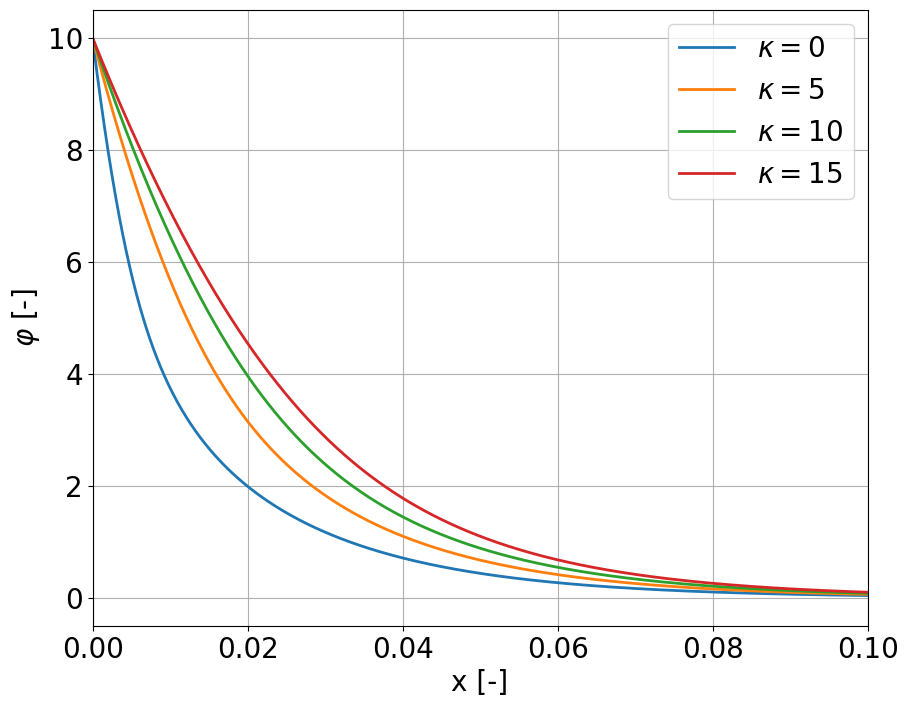

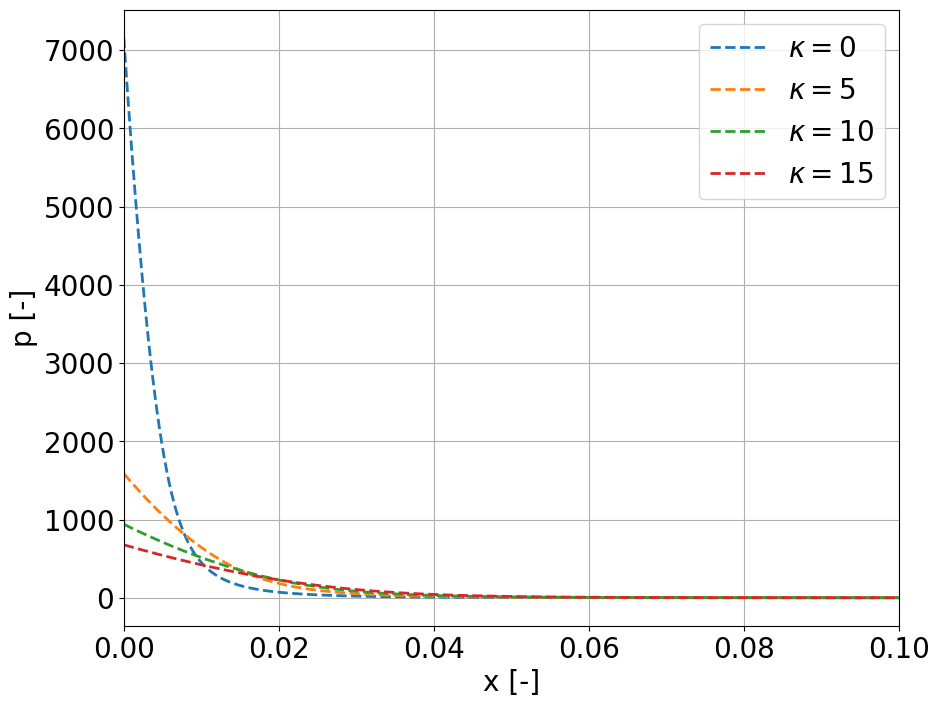

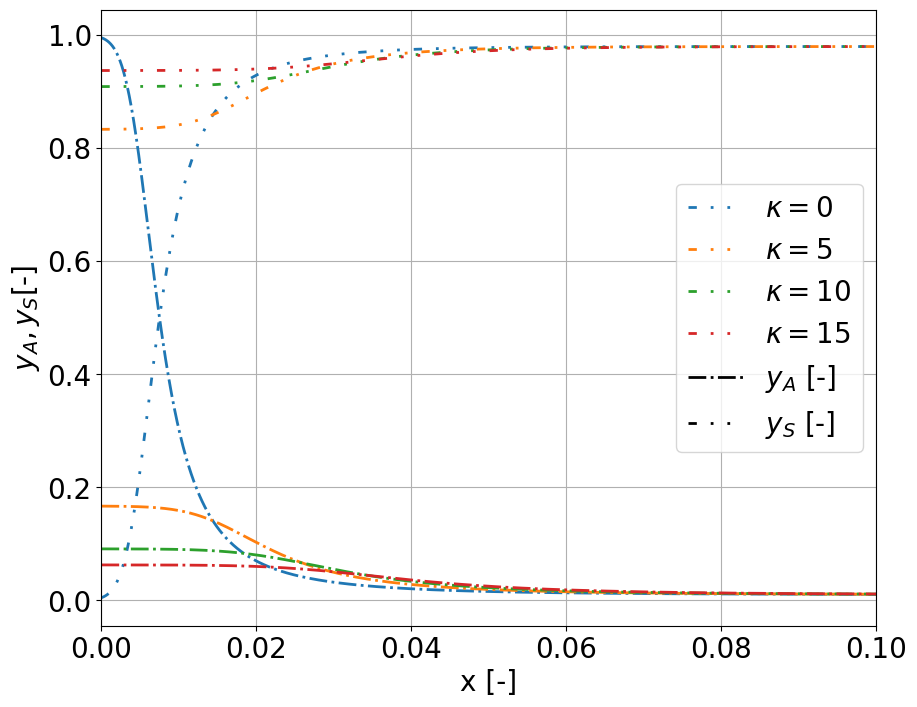

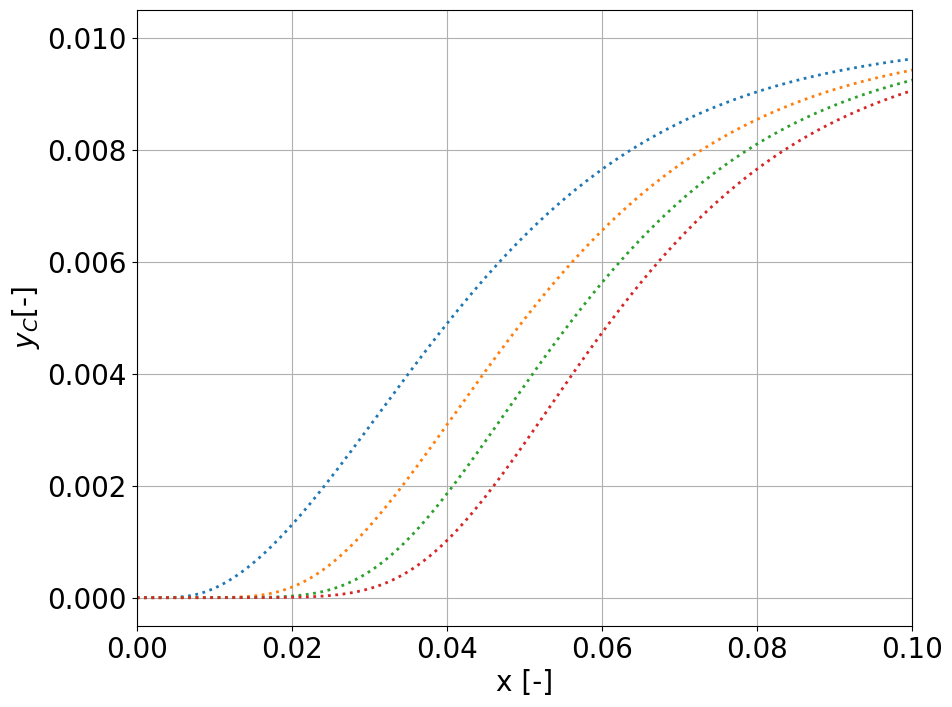

In [68]:
xlim = [0, 0.1]
figs_solvation = []
for property_, marker_, label_, prop_label_ in zip([phi_solvation, p_solvation], [marker_phi, marker_p], ['$\\varphi$ [-]', 'p [-]'], ['phi', 'p']):
    fig, axs = plt.subplots(1, 1, figsize=(10, 8))
    for i, Solvation in enumerate(Solvation_vec):
        axs.plot(x_solvation[i], property_[i], lw=linewidth, linestyle=marker_, color=colors[i], label=f'$\kappa = {Solvation}$')
    axs.grid()
    axs.set_xlabel('x [-]', fontsize=labelsize)
    axs.set_ylabel(label_, fontsize=labelsize)
    axs.tick_params(axis='both', labelsize=labelsize)
    axs.set_xlim(xlim)
    axs.legend(fontsize=labelsize, loc='best')
    figs_solvation.append(fig)
    fig.savefig(f'../Figures/Solvation/{prop_label_}.pdf', bbox_inches='tight')

fig, axs = plt.subplots(1, 1, figsize=(10, 8))
for i, Solvation in enumerate(Solvation_vec):
    for property_, marker_, label_ in zip([y_A_solvation, y_S_solvation], [marker_y_A, markers_y_S], ['$y_A$ [-]', '$y_S$ [-]']):
        axs.plot(x_solvation[i], property_[i], lw=linewidth, linestyle=marker_, color=colors[i])
    dummy = axs.plot([], [], lw=linewidth, linestyle=marker_, color=colors[i], label=f'$\kappa = {Solvation}$')
for marker_, label_ in zip([marker_y_A, markers_y_S], ['$y_A$ [-]', '$y_S$ [-]']):
    dummy = axs.plot([], [], lw=linewidth, linestyle=marker_, color=color_default, label=label_)
axs.grid()
axs.set_xlabel('x [-]', fontsize=labelsize)
axs.set_ylabel('$y_A, y_S$[-]', fontsize=labelsize)
axs.tick_params(axis='both', labelsize=labelsize)
axs.set_xlim(xlim)
axs.legend(fontsize=labelsize, loc='best')
figs_solvation.append(fig)
fig.savefig(f'../Figures/Solvation/yA_y_S.pdf', bbox_inches='tight')

fig, axs = plt.subplots(1, 1, figsize=(10, 8))
for i, Solvation in enumerate(Solvation_vec):
    for property_, marker_, label_ in zip([y_C_solvation], [marker_y_C], ['$y_C$ [-]']):
        axs.plot(x_solvation[i], property_[i], lw=linewidth, linestyle=marker_, color=colors[i])
    dummy = axs.plot([], [], lw=linewidth, linestyle=marker_, color=colors[i], label=f'$\kappa = {Solvation}$')
axs.grid()
axs.set_xlabel('x [-]', fontsize=labelsize)
axs.set_ylabel('$y_C$[-]', fontsize=labelsize)
axs.tick_params(axis='both', labelsize=labelsize)
axs.set_xlim(xlim)
figs_solvation.append(fig)
fig.savefig(f'../Figures/Solvation/y_C.pdf', bbox_inches='tight')

[fig_.show() for fig_ in figs_solvation]

## Compressibility

In [17]:
df_compressibility_path = '../Data/Compressibility.npz'
df_compressibility = np.load(df_compressibility_path)

x_compressibility = df_compressibility['x']
phi_compressibility = df_compressibility['phi']
p_compressibility = df_compressibility['p']
y_A_compressibility = df_compressibility['y_A']
y_C_compressibility = df_compressibility['y_C']
y_S_compressibility = df_compressibility['y_S']
K_vec_compressibility = df_compressibility['K_vec']
n_compressibility = df_compressibility['n']

/tmp/ipykernel_206344/2513406640.py:60: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  [fig_.show() for fig_ in figs_compressibility]


[None, None, None, None]

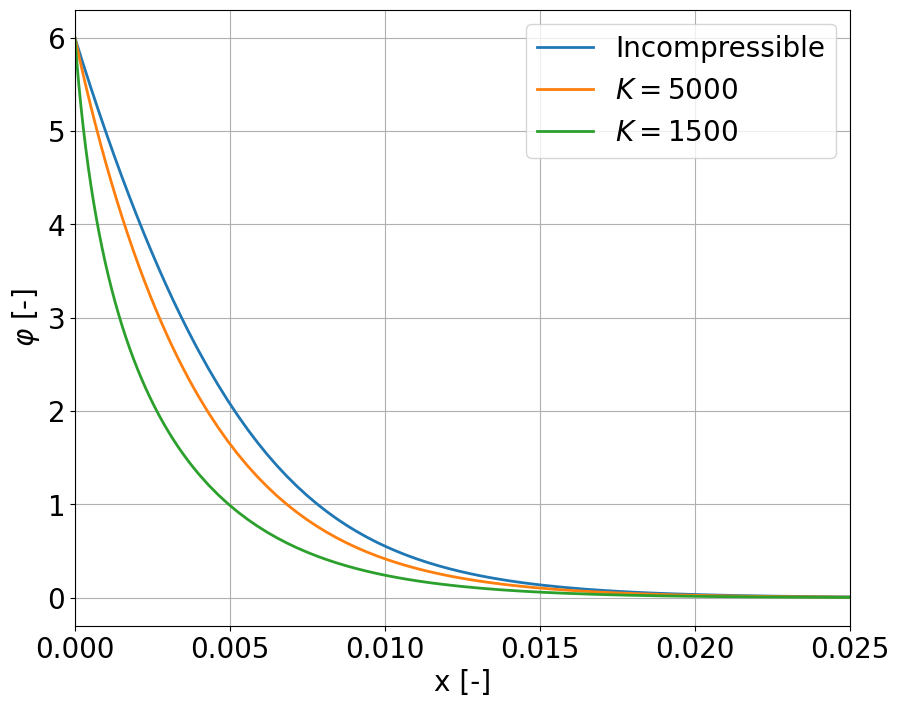

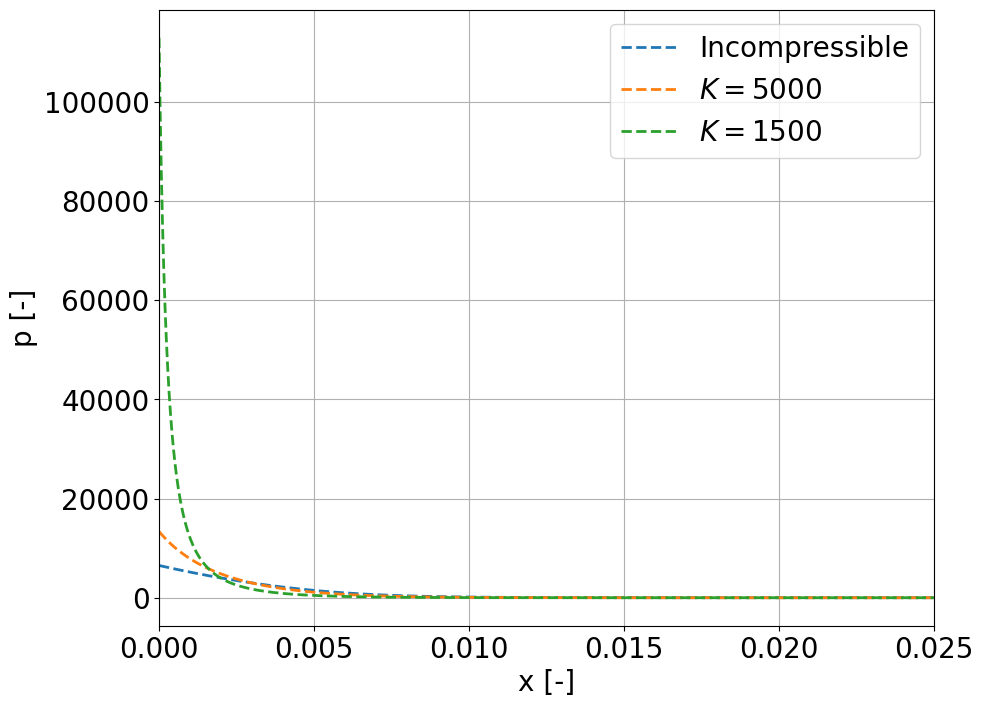

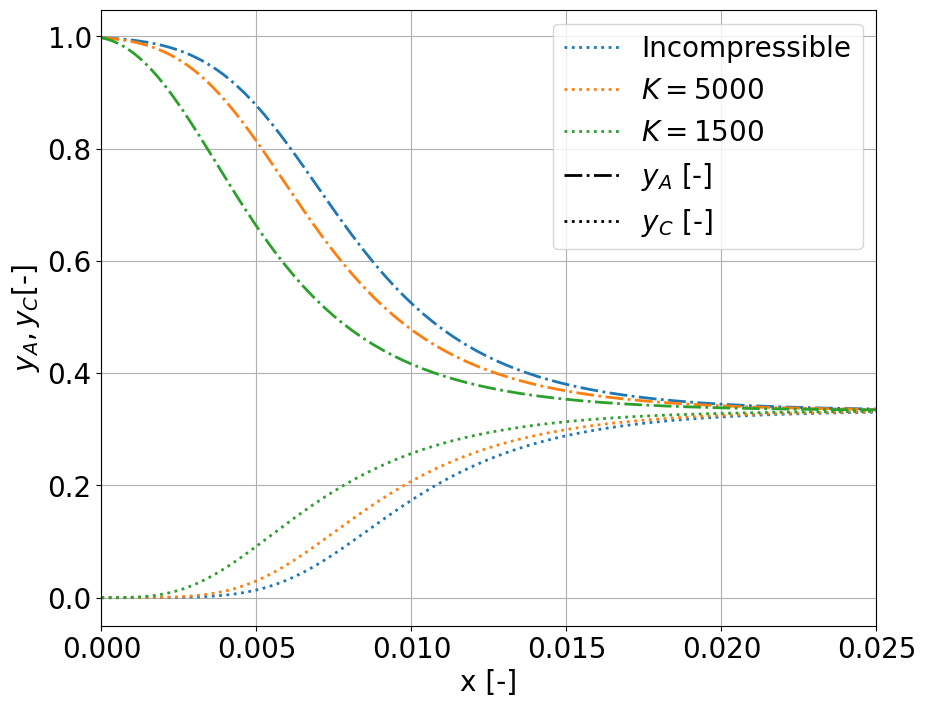

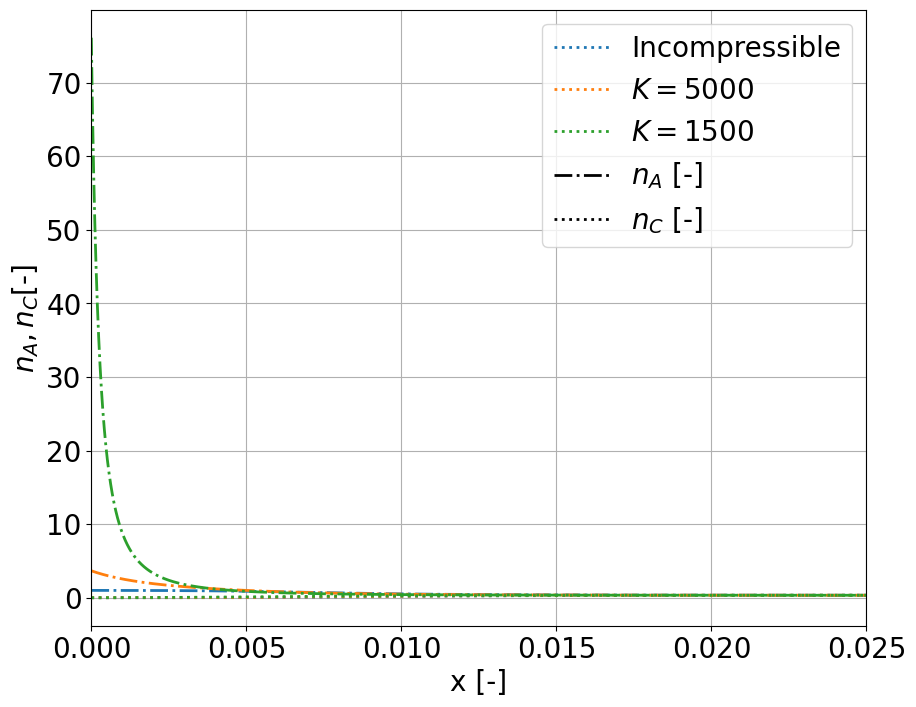

In [69]:
xlim = [0, 0.025]
figs_compressibility = []
# Potential and pressure
for property_, marker_, label_, prop_label_ in zip([phi_compressibility, p_compressibility], [marker_phi, marker_p], ['$\\varphi$ [-]', 'p [-]'], ['phi', 'p']):
    fig, axs = plt.subplots(1, 1, figsize=(10, 8))
    for i, K in enumerate(K_vec_compressibility[:-1]):
        if K == 'incompressible':
            axs.plot(x_compressibility[i], property_[i], lw=linewidth, linestyle=marker_, color=colors[i], label=f'Incompressible')
        else:
            axs.plot(x_compressibility[i], property_[i], lw=linewidth, linestyle=marker_, color=colors[i], label=f'$K = {K}$')
    axs.grid()
    axs.set_xlabel('x [-]', fontsize=labelsize)
    axs.set_ylabel(label_, fontsize=labelsize)
    axs.tick_params(axis='both', labelsize=labelsize)
    axs.set_xlim(xlim)
    axs.legend(fontsize=labelsize, loc='best')
    figs_compressibility.append(fig)
    fig.savefig(f'../Figures/Compressibility/{prop_label_}.pdf', bbox_inches='tight')

# Atomic fractions
fig, axs = plt.subplots(1, 1, figsize=(10, 8))
for i, K in enumerate(K_vec_compressibility[:-1]):
    for property_, marker_, label_ in zip([y_A_compressibility, y_C_compressibility], [marker_y_A, marker_y_C], ['$y_A$ [-]', '$y_C$ [-]']):
        axs.plot(x_compressibility[i], property_[i], lw=linewidth, linestyle=marker_, color=colors[i])
    if K == 'incompressible':
        dummy = axs.plot([], [], lw=linewidth, linestyle=marker_, color=colors[i], label=f'Incompressible')
    else:
        dummy = axs.plot([], [], lw=linewidth, linestyle=marker_, color=colors[i], label=f'$K = {K}$')
for marker_, label_ in zip([marker_y_A, marker_y_C], ['$y_A$ [-]', '$y_C$ [-]']):
    dummy = axs.plot([], [], lw=linewidth, linestyle=marker_, color=color_default, label=label_)
axs.grid()
axs.set_xlabel('x [-]', fontsize=labelsize)
axs.set_ylabel('$y_A, y_C$[-]', fontsize=labelsize)
axs.tick_params(axis='both', labelsize=labelsize)
axs.set_xlim(xlim)
axs.legend(fontsize=labelsize, loc='best')
figs_compressibility.append(fig)
fig.savefig(f'../Figures/Compressibility/y_A_y_C.pdf', bbox_inches='tight')

# Number densities
fig, axs = plt.subplots(1, 1, figsize=(10, 8))
for i, K in enumerate(K_vec_compressibility[:-1]):
    for property_, marker_, label_ in zip([y_A_compressibility, y_C_compressibility], [marker_y_A, marker_y_C], ['$n_A$ [-]', '$N_C$ [-]']):
        axs.plot(x_compressibility[i], property_[i] * n_compressibility[i], lw=linewidth, linestyle=marker_, color=colors[i])
    if K == 'incompressible':
        dummy = axs.plot([], [], lw=linewidth, linestyle=marker_, color=colors[i], label=f'Incompressible')
    else:
        dummy = axs.plot([], [], lw=linewidth, linestyle=marker_, color=colors[i], label=f'$K = {K}$')
for marker_, label_ in zip([marker_y_A, marker_y_C], ['$n_A$ [-]', '$n_C$ [-]']):
    dummy = axs.plot([], [], lw=linewidth, linestyle=marker_, color=color_default, label=label_)
axs.grid()
axs.set_xlabel('x [-]', fontsize=labelsize)
axs.set_ylabel('$n_A, n_C$[-]', fontsize=labelsize)
axs.tick_params(axis='both', labelsize=labelsize)
axs.set_xlim(xlim)
axs.legend(fontsize=labelsize, loc='best')
figs_compressibility.append(fig)
fig.savefig(f'../Figures/Compressibility/n_A_n_C.pdf', bbox_inches='tight')

[fig_.show() for fig_ in figs_compressibility]

## Double Layer Capacity

### Molarity

In [40]:
data_Molarity_path = '../Data/DoubleLayerCapacity/Molarity.npz'
data_Molarity = np.load(data_Molarity_path)

Q_DL_Molarity = data_Molarity['Q_DL_dimless_']
Phi_Pot_DL_Molarity = data_Molarity['Phi_Pot_Diff_dimless']
C_DL_DL_Molarity = data_Molarity['C_DL_dimless']
Molarity_DL_Molarity = data_Molarity['Molarity']

data_PB_Molarity_path = '../Data/DoubleLayerCapacity/PB.npz'
data_PB_Molarity = np.load(data_PB_Molarity_path)

Q_DL_PB_Molarity = data_PB_Molarity['Q_DL_dimless_PB_']
Phi_Pot_DL_PB_Molarity = data_PB_Molarity['Phi_Pot_Diff_dimless_PB']
Phi_Pot_center_array_DL_PB_Molarity = data_PB_Molarity['Phi_pot_center_array_dimless_PB']
C_DL_DL_PB_Molarity = data_PB_Molarity['C_DL_dimless_PB']
Molarity_DL_PB_Molarity = data_PB_Molarity['Molarity']

<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:20: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:20: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_206344/997720569.py:7: SyntaxWarning: invalid escape sequence '\d'
  axs.set_xlabel('$\delta \\varphi$ [-]', fontsize=labelsize)
/tmp/ipykernel_206344/997720569.py:20: SyntaxWarning: invalid escape sequence '\d'
  axs.set_xlabel('$\delta \\varphi$ [-]', fontsize=labelsize)
/tmp/ipykernel_206344/997720569.py:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_Charge_Molarity.show()
/tmp/ipykernel_206344/997720569.py:28: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_DLKap_Molarity.show()


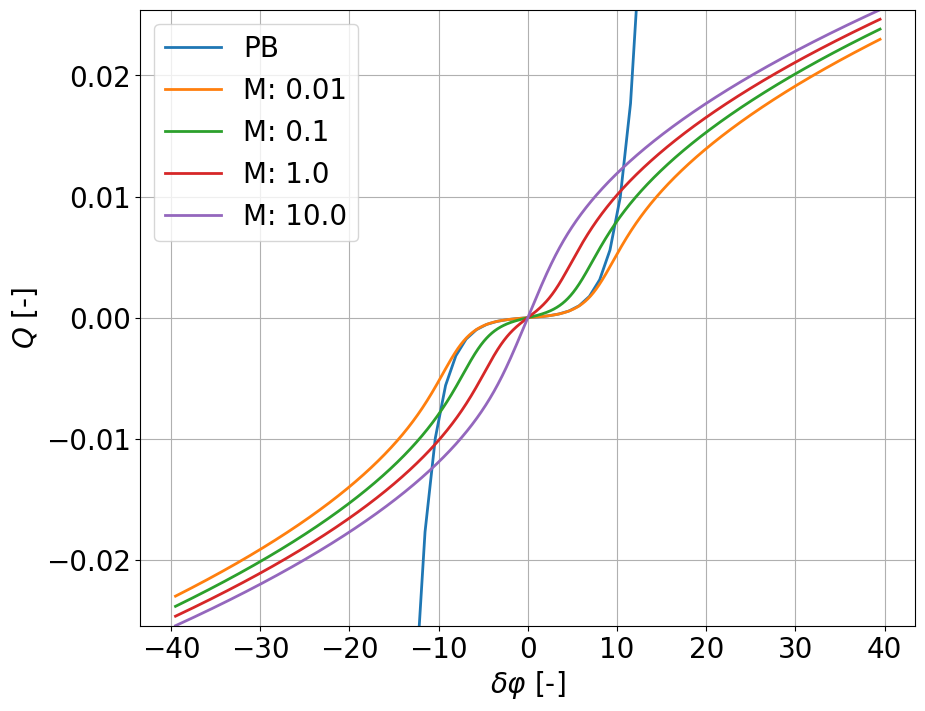

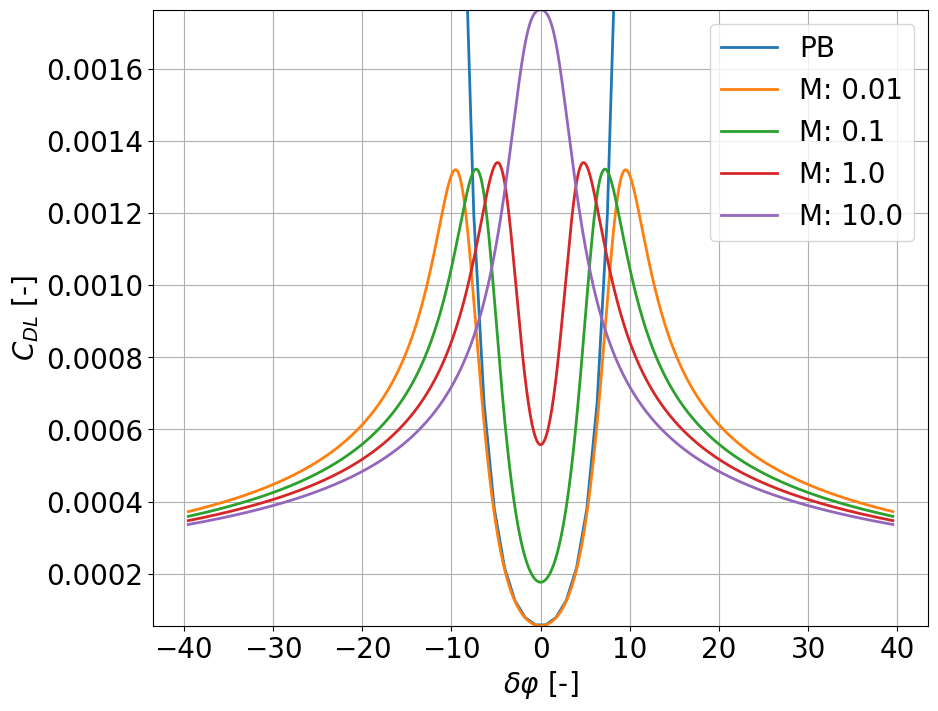

In [70]:
# Charge
fig_Charge_Molarity, axs = plt.subplots(1, 1, figsize=(10, 8))
axs.plot(Phi_Pot_DL_PB_Molarity, Q_DL_PB_Molarity, lw=linewidth, linestyle=marker_phi, color=colors[0], label='PB') # ToDo: Change marker
for i, q_dl in enumerate(Q_DL_Molarity):
    axs.plot(Phi_Pot_DL_Molarity, q_dl, lw=linewidth, linestyle=marker_phi, color=colors[i+1], label=f'M: {Molarity_DL_Molarity[i]}')
axs.grid()
axs.set_xlabel('$\delta \\varphi$ [-]', fontsize=labelsize)
axs.set_ylabel('$Q$ [-]', fontsize=labelsize)
axs.tick_params(axis='both', labelsize=labelsize)
axs.legend(fontsize=labelsize, loc='best')
axs.set_ylim(np.min(Q_DL_Molarity), np.max(Q_DL_Molarity))
fig_Charge_Molarity.savefig('../Figures/DoubleLayerCapacity/Molarity/Charge.pdf', bbox_inches='tight')

# Double Layer Capacity
fig_DLKap_Molarity, axs = plt.subplots(1, 1, figsize=(10, 8))
axs.plot(Phi_Pot_center_array_DL_PB_Molarity, C_DL_DL_PB_Molarity, lw=linewidth, linestyle=marker_phi, color=colors[0], label='PB') # ToDo: Change marker
for i, C_dl in enumerate(C_DL_DL_Molarity):
    axs.plot(Phi_Pot_DL_Molarity, C_dl, lw=linewidth, linestyle=marker_phi, color=colors[i+1], label=f'M: {Molarity_DL_Molarity[i]}')
axs.grid()
axs.set_xlabel('$\delta \\varphi$ [-]', fontsize=labelsize)
axs.set_ylabel('$C_{DL}$ [-]', fontsize=labelsize)
axs.tick_params(axis='both', labelsize=labelsize)
axs.legend(fontsize=labelsize, loc='best')
axs.set_ylim(np.min(C_DL_DL_Molarity), np.max(C_DL_DL_Molarity))
fig_DLKap_Molarity.savefig('../Figures/DoubleLayerCapacity/Molarity/Capacity.pdf', bbox_inches='tight')

fig_Charge_Molarity.show()
fig_DLKap_Molarity.show()

### $\lambda^2$

In [51]:
data_Lambda2_path = '../Data/DoubleLayerCapacity/Lambda.npz'
data_Lambda2 = np.load(data_Lambda2_path)

Q_DL_Lambda2 = data_Lambda2['Q_DL_dimless_']
Phi_Pot_DL_Lambda2 = data_Lambda2['Phi_Pot_Diff_dimless']
C_DL_DL_Lambda2 = data_Lambda2['C_DL_dimless']
Lambda2_DL_Lambda2 = data_Lambda2['Lambda2_vec']

<>:4: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:16: SyntaxWarning: invalid escape sequence '\l'
<>:18: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:16: SyntaxWarning: invalid escape sequence '\l'
<>:18: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_206344/1649007776.py:4: SyntaxWarning: invalid escape sequence '\l'
  axs.plot(Phi_Pot_DL_Lambda2, q_dl, lw=linewidth, linestyle=marker_phi, color=colors[i+1], label=f'$\lambda^2$: {Lambda2_DL_Lambda2[i]}')
/tmp/ipykernel_206344/1649007776.py:6: SyntaxWarning: invalid escape sequence '\d'
  axs.set_xlabel('$\delta \\varphi$ [-]', fontsize=labelsize)
/tmp/ipykernel_206344/1649007776.py:16: SyntaxWarning: invalid escape sequence '\l'
  axs.plot(Phi_Pot_DL_Lambda2, C_dl, lw=linewidth, linestyle=marker_phi, color=colors[i+1], label=f'$\lambda^2$: {Lambda2_DL_Lambda2[i]}')
/tmp/i

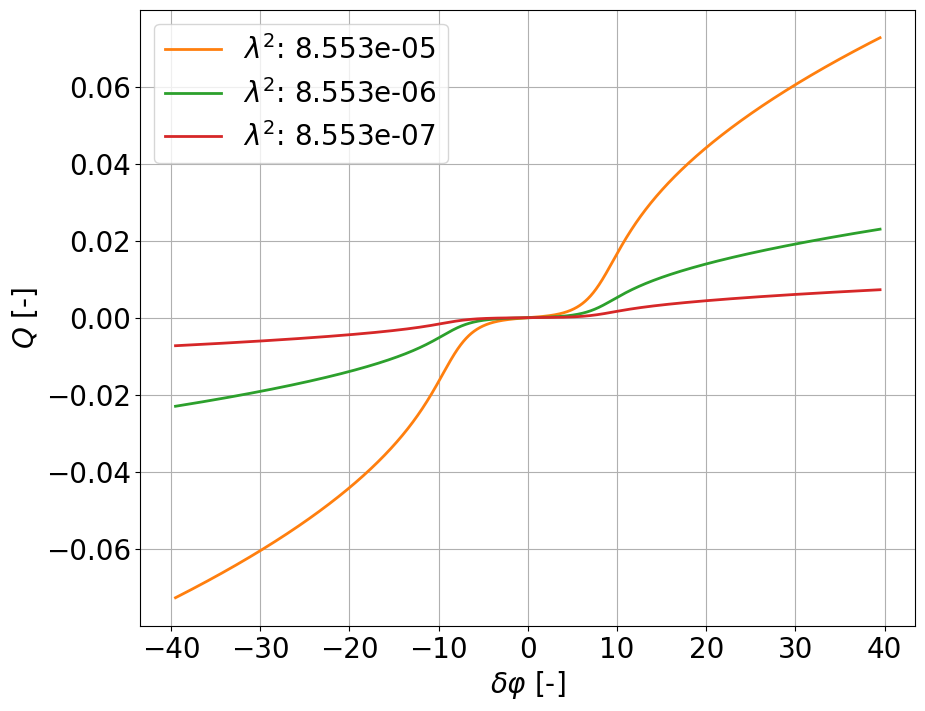

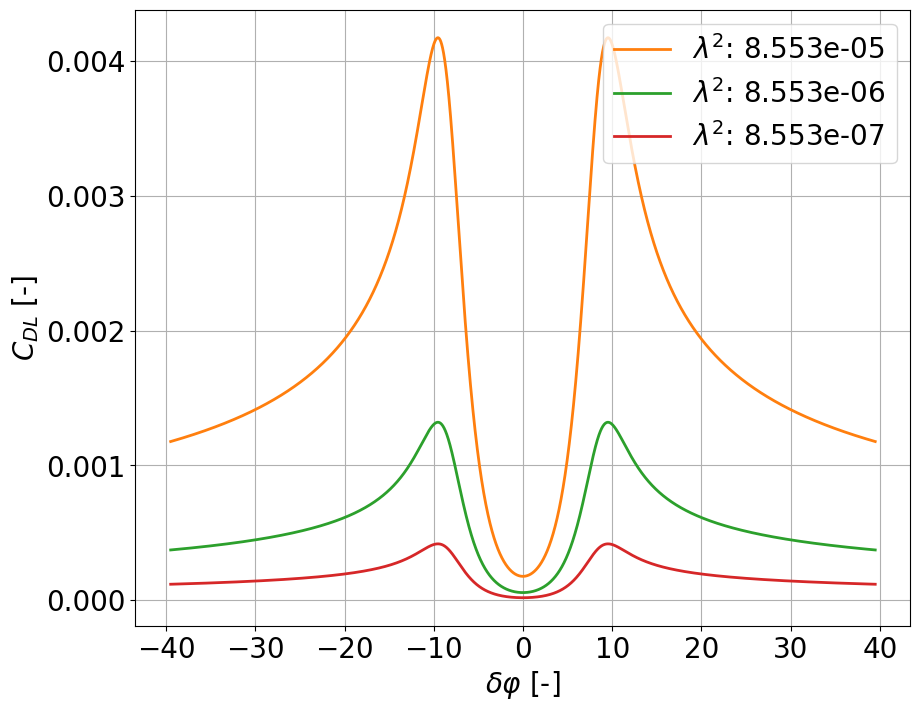

In [72]:
# Charge
fig_Charge_Lambda2, axs = plt.subplots(1, 1, figsize=(10, 8))
for i, q_dl in enumerate(Q_DL_Lambda2):
    axs.plot(Phi_Pot_DL_Lambda2, q_dl, lw=linewidth, linestyle=marker_phi, color=colors[i+1], label=f'$\lambda^2$: {Lambda2_DL_Lambda2[i]}')
axs.grid()
axs.set_xlabel('$\delta \\varphi$ [-]', fontsize=labelsize)
axs.set_ylabel('$Q$ [-]', fontsize=labelsize)
axs.tick_params(axis='both', labelsize=labelsize)
axs.legend(fontsize=labelsize, loc='best')
# axs.set_ylim(np.min(Q_DL_Lambda2), np.max(Q_DL_Lambda2))
fig_Charge_Lambda2.savefig('../Figures/DoubleLayerCapacity/Lambda2/Charge.pdf', bbox_inches='tight')

# Double Layer Capacity
fig_DLKap_Lambda2, axs = plt.subplots(1, 1, figsize=(10, 8))
for i, C_dl in enumerate(C_DL_DL_Lambda2):
    axs.plot(Phi_Pot_DL_Lambda2, C_dl, lw=linewidth, linestyle=marker_phi, color=colors[i+1], label=f'$\lambda^2$: {Lambda2_DL_Lambda2[i]}')
axs.grid()
axs.set_xlabel('$\delta \\varphi$ [-]', fontsize=labelsize)
axs.set_ylabel('$C_{DL}$ [-]', fontsize=labelsize)
axs.tick_params(axis='both', labelsize=labelsize)
axs.legend(fontsize=labelsize, loc='best')
# axs.set_ylim(np.min(C_DL_DL_Lambda2), np.max(C_DL_DL_Lambda2))
fig_DLKap_Lambda2.savefig('../Figures/DoubleLayerCapacity/Lambda2/Capacity.pdf', bbox_inches='tight')

fig_Charge_Lambda2.show()
fig_DLKap_Lambda2.show()

### Compressibility

In [52]:
data_Compressibility_path = '../Data/DoubleLayerCapacity/DLKap_Compressibility.npz'
data_Compressibility = np.load(data_Compressibility_path)

Q_DL_Compressibility = data_Compressibility['Q_DL_dimless_']
Phi_Pot_DL_Compressibility = data_Compressibility['Phi_Pot_Diff_dimless']
C_DL_DL_Compressibility = data_Compressibility['C_DL_dimless']
Compressibility_DL_Compressibility = data_Compressibility['K_vec']

<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:18: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:18: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_206344/2473916223.py:6: SyntaxWarning: invalid escape sequence '\d'
  axs.set_xlabel('$\delta \\varphi$ [-]', fontsize=labelsize)
/tmp/ipykernel_206344/2473916223.py:18: SyntaxWarning: invalid escape sequence '\d'
  axs.set_xlabel('$\delta \\varphi$ [-]', fontsize=labelsize)
/tmp/ipykernel_206344/2473916223.py:25: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_Charge_Compressibility.show()
/tmp/ipykernel_206344/2473916223.py:26: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_DLKap_Compressibility.show()


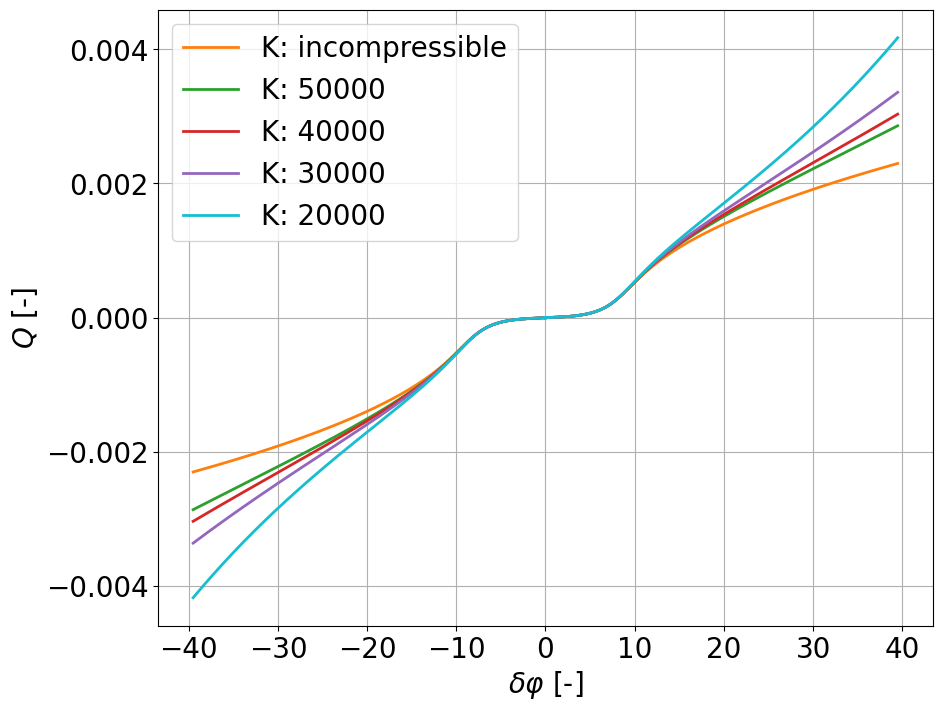

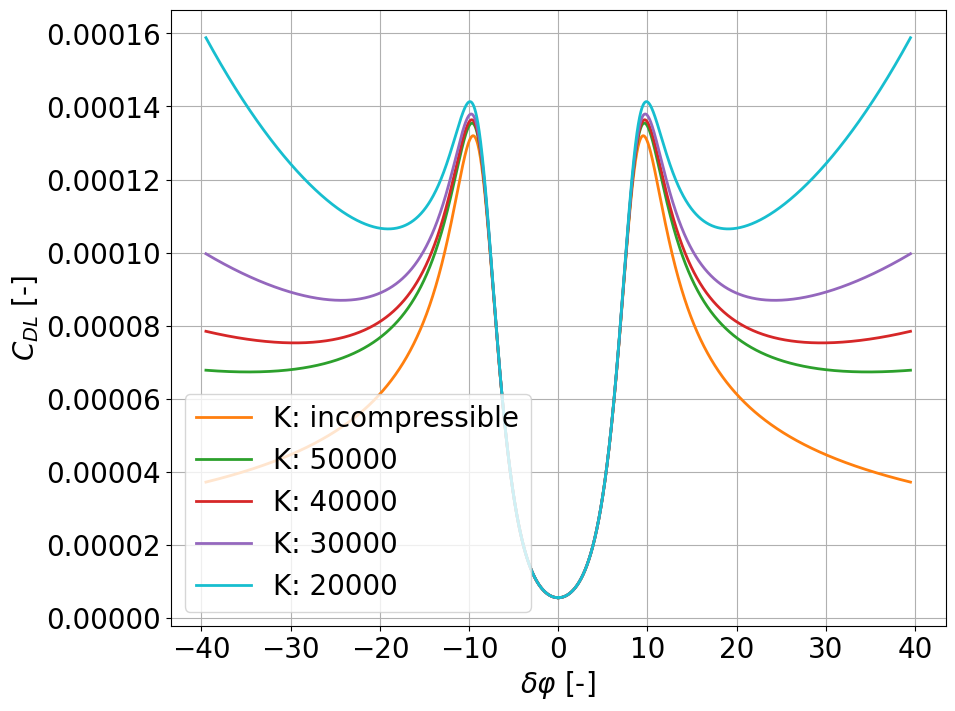

In [74]:
# Charge
fig_Charge_Compressibility, axs = plt.subplots(1, 1, figsize=(10, 8))
for i, q_dl in enumerate(Q_DL_Compressibility):
    axs.plot(Phi_Pot_DL_Compressibility, q_dl, lw=linewidth, linestyle=marker_phi, color=colors[i+1], label=f'K: {Compressibility_DL_Compressibility[i]}')
axs.grid()
axs.set_xlabel('$\delta \\varphi$ [-]', fontsize=labelsize)
axs.set_ylabel('$Q$ [-]', fontsize=labelsize)
axs.tick_params(axis='both', labelsize=labelsize)
axs.legend(fontsize=labelsize, loc='best')
# axs.set_ylim(np.min(Q_DL_Compressibility), np.max(Q_DL_Compressibility))
fig_Charge_Compressibility.savefig('../Figures/DoubleLayerCapacity/Compressibility/Charge.pdf', bbox_inches='tight')

# Double Layer Capacity
fig_DLKap_Compressibility, axs = plt.subplots(1, 1, figsize=(10, 8))
for i, C_dl in enumerate(C_DL_DL_Compressibility):
    axs.plot(Phi_Pot_DL_Compressibility, C_dl, lw=linewidth, linestyle=marker_phi, color=colors[i+1], label=f'K: {Compressibility_DL_Compressibility[i]}')
axs.grid()
axs.set_xlabel('$\delta \\varphi$ [-]', fontsize=labelsize)
axs.set_ylabel('$C_{DL}$ [-]', fontsize=labelsize)
axs.tick_params(axis='both', labelsize=labelsize)
axs.legend(fontsize=labelsize, loc='best')
# axs.set_ylim(np.min(C_DL_DL_Compressibility), np.max(C_DL_DL_Compressibility))
fig_DLKap_Compressibility.savefig('../Figures/DoubleLayerCapacity/Compressibility/Capacity.pdf', bbox_inches='tight')

fig_Charge_Compressibility.show()
fig_DLKap_Compressibility.show()